In [1]:
from __future__ import annotations

import os
import re
from datetime import datetime, timedelta
from typing import Any, Dict, Optional, Sequence, Tuple, Union

import numpy as np
from netCDF4 import Dataset, chartostring
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap

import cartopy.feature as cfeature


# -----------------------------
# Lon helpers
# -----------------------------
def lon_to_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0


def zlabel_from_Ztyp(ztyp: int) -> str:
    ztyp = int(ztyp)
    if ztyp == -2: return "unspecified"
    if ztyp == -1: return "surface"
    if ztyp ==  1: return "level"
    if ztyp ==  2: return "pressure"
    if ztyp ==  3: return "height"
    return "z"


# -----------------------------
# 3D "floor" feature plotting
# -----------------------------
def add_feature_floor_clipped(ax, feature, z0, extent,
                             *, facecolor=None, edgecolor="k", lw=0.8, alpha=1.0):
    """
    Draw a cartopy feature (COASTLINE/BORDERS/STATES) as 3D lines at z=z0.
    extent = (xmin, xmax, ymin, ymax) in the SAME lon/lat coords you plot.
    """
    xmin, xmax, ymin, ymax = extent

    # Optional shapely clipping (best)
    try:
        import shapely.geometry as sgeom
    except Exception:
        sgeom = None

    bbox = sgeom.box(xmin, ymin, xmax, ymax) if sgeom is not None else None

    try:
        geoms = list(feature.geometries())
    except Exception:
        return

    def _plot_linestring(ls):
        xs, ys = ls.xy
        xs = np.asarray(xs); ys = np.asarray(ys)
        m = (xs >= xmin) & (xs <= xmax) & (ys >= ymin) & (ys <= ymax)
        if m.any():
            ax.plot(xs[m], ys[m], zs=z0, zdir="z",
                    color=edgecolor, linewidth=lw, alpha=alpha)

    for g in geoms:
        gg = g
        if bbox is not None:
            gg = gg.intersection(bbox)
            if gg.is_empty:
                continue

        if gg.geom_type == "LineString":
            _plot_linestring(gg)
        elif gg.geom_type == "MultiLineString":
            for ls in gg.geoms:
                _plot_linestring(ls)
        # We ignore polygon fills for now (coastlines/borders/states are lines)


# -----------------------------
# NetCDF helper translations
# -----------------------------
def nc_var_exists(fname: str, varname: str) -> Tuple[bool, Optional[str]]:
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")
    key = str(varname).strip()
    with Dataset(fname, "r") as ds:
        present = key in ds.variables
    return present, (key if present else None)


def nc_read_att(fname: str, varid: str, attname: str) -> Any:
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")
    att = str(attname).strip()
    with Dataset(fname, "r") as ds:
        if varid == "/":
            return ds.getncattr(att) if att in ds.ncattrs() else None
        v = ds.variables.get(varid, None)
        if v is None:
            return None
        return v.getncattr(att) if att in v.ncattrs() else None


def nc_dim_info(fname: str, dimname: str) -> Tuple[Optional[int], Optional[str]]:
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")
    key = str(dimname).strip()
    with Dataset(fname, "r") as ds:
        if key in ds.dimensions:
            return len(ds.dimensions[key]), key
    return None, None


def _read_nc_string_list(fname: str, varname: str) -> list[str]:
    """
    Read DART-style metadata vars (QCMetaData, CopyMetaData, ObsTypesMetaData)
    using netCDF dimension order (deterministic, no heuristic).
    """
    with Dataset(fname, "r") as ds:
        v = ds.variables[varname]
        raw = np.array(v[:])

        # vlen strings
        if raw.ndim == 1 and raw.dtype.kind in ("S", "U"):
            out = []
            for x in raw:
                if isinstance(x, (bytes, np.bytes_)):
                    out.append(x.decode(errors="ignore").replace("\x00", "").strip())
                else:
                    out.append(str(x).replace("\x00", "").strip())
            return out

        if raw.ndim != 2:
            raise ValueError(f"{varname} unexpected shape {raw.shape} dims={v.dimensions}")

        if raw.dtype.kind == "U":
            raw = raw.astype("S1")

        dims = v.dimensions
        if "stringlength" in dims and dims.index("stringlength") == 0:
            raw = raw.T

        sarr = chartostring(raw)  # shape (n,)
        return [str(s).replace("\x00", "").strip() for s in np.array(sarr).tolist()]


def get_copy_index(fname: str, copystring: str, context: str = "CopyString", fatal: bool = True) -> int:
    copy_meta = _read_nc_string_list(fname, "CopyMetaData")

    def norm(s: str) -> str:
        return "".join(ch for ch in s.replace("\x00", "") if not ch.isspace())

    target = norm(copystring)

    idx = -1
    for i, md in enumerate(copy_meta):
        if norm(md) == target:
            idx = i

    if idx < 0 and fatal:
        errorstring = f'\nERROR: "{copystring.strip()}" is not a valid CopyMetaData value for file {fname}\n'
        msgstring = f'valid CopyMetaData values for "{context}" are'
        for md in copy_meta:
            msgstring += f"\n{md}"
        raise ValueError(f"{errorstring}\n{msgstring}")

    return idx


def get_qc_index(fname: str, qcstring: str, context: str = "QCString") -> int:
    qc_meta = _read_nc_string_list(fname, "QCMetaData")

    def norm(s: str) -> str:
        return "".join(ch for ch in s.replace("\x00", "") if not ch.isspace())

    target = norm(qcstring)

    idx = -1
    for i, md in enumerate(qc_meta):
        if norm(md) == target:
            idx = i

    if idx < 0:
        errorstring = f'\nERROR: "{qcstring.strip()}" is not a valid QCMetaData value for file {fname}\n'
        msgstring = f'valid values for "{context}" are'
        for md in qc_meta:
            msgstring += f"\n{md}"
        raise ValueError(f"{errorstring}\n{msgstring}")

    # print(f"{qcstring} is QC copy {idx+1:3d}")
    return idx


def locations_in_region(locations: np.ndarray, region: Sequence[float]) -> np.ndarray:
    region = np.asarray(region, dtype=float)

    if len(region) == 6:
        zmin = float(np.min(region[4:6]))
        zmax = float(np.max(region[4:6]))
    elif len(region) == 4:
        zmin, zmax = -np.inf, np.inf
    else:
        raise ValueError("region must be an array of length 4 or 6")

    ymin = float(np.min(region[2:4]))
    ymax = float(np.max(region[2:4]))
    xmin = float(np.mod(region[0], 360.0))
    xmax = float(np.mod(region[1], 360.0))

    loc = np.asarray(locations, dtype=float)
    lons = np.mod(loc[:, 0], 360.0)

    latlogical = (loc[:, 1] >= ymin) & (loc[:, 1] <= ymax)
    lvllogical = (loc[:, 2] >= zmin) & (loc[:, 2] <= zmax)

    if xmin == xmax:
        lonlogical = np.ones_like(latlogical, dtype=bool)
    else:
        if xmin > xmax:
            xmax = xmax + 360.0
            wrap_inds = np.where(lons < xmin)[0]
            lons = lons.copy()
            lons[wrap_inds] += 360.0
        lonlogical = (lons >= xmin) & (lons <= xmax)

    return np.where(lonlogical & latlogical & lvllogical)[0]


# -----------------------------
# Plot helpers
# -----------------------------
def add_gray_color(datarange=None, *, cmap=None, ncolors=256):
    if datarange is None:
        datarange = mpl.pyplot.gca().get_clim()

    cmin, cmax = float(datarange[0]), float(datarange[1])
    if cmap is None:
        cmap = mpl.pyplot.get_cmap()

    colors = cmap(np.linspace(0, 1, ncolors))
    colors[0, :3] = 0.7
    colors[0, 3] = 1.0
    cmap2 = ListedColormap(colors)

    if cmin != cmax:
        dz = np.linspace(cmin, cmax, ncolors - 1)
        dclim = float(dz[1] - dz[0])
        clim = (cmin - dclim, cmax)
    else:
        clim = (cmin - 1.5, cmin + 1.5)

    return clim, (cmin, cmax), cmap2


def scaleme(x: np.ndarray, minsize: float) -> np.ndarray:
    x = np.asarray(x)
    maxsize = 10.0 * minsize
    minx = np.nanmin(x)
    maxx = np.nanmax(x)
    if maxx == minx:
        return np.full_like(x, fill_value=minsize, dtype=float)
    slope = (maxsize - minsize) / (maxx - minx)
    b = minsize - slope * minx
    return x * slope + b


# def apply_missing(fname: str, varname: str, *, nobs: Optional[int] = None) -> np.ndarray:
#     with Dataset(fname, "r") as ds:
#         arr = np.array(ds.variables[varname][:])

#     if arr.ndim == 2 and nobs is not None:
#         if arr.shape[0] == nobs:
#             pass
#         elif arr.shape[1] == nobs:
#             arr = arr.T

#     missing = nc_read_att(fname, varname, "missing_value")
#     if missing is not None and missing != "":
#         arr = arr.astype(float, copy=False)
#         arr[arr == missing] = np.nan

#     return arr

def apply_missing(fname: str, varname: str, *, nobs: Optional[int] = None) -> np.ndarray:
    """
    Read a variable and replace NetCDF missing/fill values with NaN.

    Handles:
      - missing_value
      - _FillValue
      - fill_value (less common)
    Also tolerates scalar or vector attributes.
    """
    with Dataset(fname, "r") as ds:
        v = ds.variables[varname]
        arr = np.array(v[:])

        # transpose helper (kept from your original)
        if arr.ndim == 2 and nobs is not None:
            if arr.shape[0] == nobs:
                pass
            elif arr.shape[1] == nobs:
                arr = arr.T

        # collect possible fill values
        fills = []

        # variable attributes (preferred)
        for att in ("missing_value", "_FillValue", "fill_value"):
            if att in v.ncattrs():
                fills.append(v.getncattr(att))

    # flatten attribute values into a simple list of scalars
    fill_vals: list[float] = []
    for f in fills:
        if f is None or f == "":
            continue
        if np.isscalar(f):
            fill_vals.append(float(f))
        else:
            for x in np.asarray(f).ravel():
                fill_vals.append(float(x))

    # If the file uses a sentinel but forgot to advertise it (common in practice),
    # you can optionally include it here. Comment out if you dislike hard-coding.
    # Only add it if it is *actually present* to avoid unintended masking.
    if np.any(arr == -888888.0):
        fill_vals.append(-888888.0)

    if fill_vals:
        arr = arr.astype(float, copy=False)
        for mv in set(fill_vals):
            arr[arr == mv] = np.nan

    return arr

_TIME_UNITS_RE = re.compile(
    r"^\s*(\w+)\s+since\s+(\d{4})[-/](\d{1,2})[-/](\d{1,2})(?:[ T](\d{1,2}):(\d{1,2})(?::(\d{1,2}))?)?\s*$",
    re.IGNORECASE
)

def _parse_time_origin(timeunits: str) -> datetime:
    m = _TIME_UNITS_RE.match(timeunits or "")
    if not m:
        raise ValueError(f"Unrecognized time units: {timeunits!r}")
    _, yyyy, mm, dd, HH, MM, SS = m.groups()
    yyyy = int(yyyy); mm = int(mm); dd = int(dd)
    HH = int(HH) if HH is not None else 0
    MM = int(MM) if MM is not None else 0
    SS = int(SS) if SS is not None else 0
    return datetime(yyyy, mm, dd, HH, MM, SS)

def _to_datetimes(values: np.ndarray, units: str) -> np.ndarray:
    origin = _parse_time_origin(units)
    if not (units or "").lower().strip().startswith("days since"):
        raise ValueError(f"Only 'days since ...' supported. units={units!r}")
    dt_list = [origin + timedelta(days=float(v)) for v in np.asarray(values).ravel()]
    return np.array(dt_list, dtype="datetime64[s]")


# -----------------------------
# read_obs_netcdf
# -----------------------------
def read_obs_netcdf(fname: str,
                    ObsTypeString: str,
                    region: Sequence[float],
                    CopyString: str,
                    QCString: str,
                    verbose: int) -> Dict[str, Any]:

    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")

    obsstruct: Dict[str, Any] = {
        "fname": fname,
        "ObsTypeString": ObsTypeString,
        "region": np.asarray(region, dtype=float),
        "QCString": QCString,
        "verbose": verbose,
    }

    # CopyString record
    obsstruct["CopyString"] = CopyString

    with Dataset(fname, "r") as ds:
        ObsTypesMetaData = np.array(ds.variables["ObsTypesMetaData"][:])
        CopyMetaData = np.array(ds.variables["CopyMetaData"][:])
        t_raw = np.array(ds.variables["time"][:])
        obs_type = np.array(ds.variables["obs_type"][:])
        obs_keys = np.array(ds.variables["obs_keys"][:])

    ObsTypeStrings = _read_nc_string_list(fname, "ObsTypesMetaData")
    CopyStrings = _read_nc_string_list(fname, "CopyMetaData")

    present, _ = nc_var_exists(fname, "which_vert")
    if present:
        with Dataset(fname, "r") as ds:
            z_type = np.array(ds.variables["which_vert"][:])
    else:
        z_type = np.ones_like(obs_keys)

    nobs = int(obs_keys.size)
    loc = apply_missing(fname, "location", nobs=nobs)
    obs = apply_missing(fname, "observations", nobs=nobs)
    qc  = apply_missing(fname, "qc", nobs=nobs)

    timeunits = nc_read_att(fname, "time", "units")
    timerange = nc_read_att(fname, "time", "valid_range")

    try:
        tr_dt = _to_datetimes(np.asarray(timerange), str(timeunits))
        obsstruct["timestring"] = (str(tr_dt[0]), str(tr_dt[-1]))
    except Exception:
        obsstruct["timestring"] = ("", "")

    try:
        t = _to_datetimes(t_raw, str(timeunits))
    except Exception:
        t = t_raw

    if verbose > 0:
        for obtype in np.unique(obs_type):
            inds = np.where(obs_type == obtype)[0]
            myz = loc[inds, 2]
            zmin = float(np.nanmin(myz)) if myz.size else np.nan
            zmax = float(np.nanmax(myz)) if myz.size else np.nan
            label = ObsTypeStrings[int(obtype) - 1] if 1 <= int(obtype) <= len(ObsTypeStrings) else f"type {int(obtype)}"
            print(f"N = {len(inds):6d} {label:32s} (type {int(obtype):3d}) tween levels {zmin:.2f} and {zmax:.2f}")

    # copy indices
    ncopies, _ = nc_dim_info(fname, "copy")
    if (CopyString or "").lower() == "all":
        if ncopies is None:
            raise ValueError("Missing 'copy' dimension.")
        mytypeind = np.arange(ncopies, dtype=int)
    else:
        mytypeind = np.array([get_copy_index(fname, CopyString, context="CopyString")], dtype=int)

    # obs type indices
    if (ObsTypeString or "").lower() == "all":
        inds = np.arange(obs.shape[0], dtype=int)
    else:
        matches = np.array([ObsTypeString == s for s in ObsTypeStrings], dtype=bool)
        if np.any(matches):
            myind1 = int(np.where(matches)[0][0]) + 1
            inds = np.where(obs_type == myind1)[0]
        else:
            print(f"FYI - no {ObsTypeString} observations ...")
            inds = np.array([], dtype=int)

    myobs  = obs[inds, :][:, mytypeind]
    mylocs = loc[inds, :]
    mykeys = obs_keys[inds]
    myztyp = z_type[inds]
    mytime = t[inds]

    if QCString is not None and str(QCString).strip() != "":
        myQCind = get_qc_index(fname, QCString, "QCString")
        myqc = qc[inds, myQCind] if qc.ndim == 2 else qc[inds]
    else:
        myqc = np.array([])

    reg_inds = locations_in_region(mylocs, region)

    obsstruct["numobs"] = int(len(reg_inds))
    obsstruct["lons"] = mylocs[reg_inds, 0]
    obsstruct["lats"] = mylocs[reg_inds, 1]
    obsstruct["z"]    = mylocs[reg_inds, 2]
    obsstruct["obs"]  = myobs[reg_inds, :].ravel() if myobs.shape[1] == 1 else myobs[reg_inds, :]
    obsstruct["Ztyp"] = myztyp[reg_inds]
    obsstruct["keys"] = mykeys[reg_inds]
    obsstruct["time"] = mytime[reg_inds]
    obsstruct["qc"]   = myqc[reg_inds] if myqc.size else np.array([])

    # Z units logic
    ztypes = np.unique(obsstruct["Ztyp"])
    obsstruct["numZtypes"] = int(len(ztypes))
    for zt in ztypes:
        zt = int(zt)
        if zt == -2:
            obsstruct["Zpositivedir"], obsstruct["Zunits"] = "up", "unknown"
        elif zt == -1:
            obsstruct["Zpositivedir"], obsstruct["Zunits"] = "up", "surface"
        elif zt == 1:
            obsstruct["Zpositivedir"], obsstruct["Zunits"] = "down", "model level"
        elif zt == 2:
            obsstruct["Zpositivedir"], obsstruct["Zunits"] = "down", "pressure"
        elif zt == 3:
            obsstruct["Zpositivedir"], obsstruct["Zunits"] = "up", "height"
            if len(CopyStrings) >= 1 and CopyStrings[0].startswith("WOD obs"):
                obsstruct["Zpositivedir"], obsstruct["Zunits"] = "down", "depth"
        else:
            raise ValueError("not a known vertical coordinate system")

    return obsstruct


# -----------------------------
# plot_3D with "floor" coastlines/borders/states
# -----------------------------
def plot_3D(obsstruct: Dict[str, Any], pstruct: Dict[str, Any], ax: plt.Axes) -> plt.Axes:
    # Convert to [-180,180) for compatibility with NaturalEarth geometries
    lons = lon_to_180(np.asarray(obsstruct["lons"]))
    lats = np.asarray(obsstruct["lats"])
    z = np.asarray(obsstruct["z"])
    c = np.asarray(obsstruct["obs"]).ravel()
    s = np.asarray(pstruct["scalearray"]).ravel()

    sc = ax.scatter(lons, lats, z, s=s, c=c, marker="d", cmap="viridis")

    xmin, xmax, ymin, ymax, zmin, zmax = pstruct["axis"]
    # Convert x-limits to [-180,180) consistently
    xmin = float(lon_to_180(xmin))
    xmax = float(lon_to_180(xmax))
    ax.set_xlim(min(xmin, xmax), max(xmin, xmax))
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    ztyp0 = int(np.asarray(obsstruct["Ztyp"]).ravel()[0])
    if ztyp0 == 2:
        ax.invert_zaxis()

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel(zlabel_from_Ztyp(ztyp0))

    # Choose a floor plane similar to MATLAB
    z0 = zmax if ztyp0 == 2 else zmin
    extent = (min(xmin, xmax), max(xmin, xmax), ymin, ymax)

    add_feature_floor_clipped(ax, cfeature.COASTLINE.with_scale("110m"), z0, extent,
                              edgecolor="k", lw=0.8, alpha=1.0)
    add_feature_floor_clipped(ax, cfeature.BORDERS.with_scale("110m"), z0, extent,
                              edgecolor="0.2", lw=0.6, alpha=0.8)
    add_feature_floor_clipped(ax, cfeature.STATES.with_scale("50m"), z0, extent,
                              edgecolor="0.2", lw=0.6, alpha=0.8)

    ax.set_title("\n".join([pstruct["str1"], pstruct["str3"], pstruct["str2"]]))
    cb = plt.colorbar(sc, ax=ax, pad=0.03, shrink=0.5)
    cb.set_label(pstruct["colorbarstring"])
    ax.view_init(elev=30, azim=-60)
    return ax


# -----------------------------
# plot_obs_netcdf (only the plotting part shown)
# -----------------------------
def plot_obs_netcdf(fname: str,
                    ObsTypeString: str,
                    region: Sequence[float],
                    CopyString: str,
                    QCString: str,
                    maxQC: Optional[float],
                    verbose: int = 1,
                    twoup: int = 1) -> Dict[str, Any]:

    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")

    fig = plt.figure(figsize=(8, 11) if twoup > 0 else (11, 8.5))
    positions = np.array([
        [0.1, 0.55, 0.8, 0.35],
        [0.1, 0.10, 0.8, 0.35],
        [0.1, 0.02, 0.8, 0.08],
    ], dtype=float) if twoup > 0 else np.array([
        [0.1, 0.20, 0.8, 0.65],
        [0.1, 0.20, 0.8, 0.65],
        [0.1, 0.05, 0.8, 0.10],
    ], dtype=float)

    data = read_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, verbose)

    # QC filtering
    flaggedobs: Dict[str, Any] = {}
    if data.get("qc") is not None and data["qc"].size > 0 and maxQC is not None:
        bad = np.where(data["qc"] > maxQC)[0]
        good = np.where(data["qc"] <= maxQC)[0]
        data["numflagged"] = len(bad)
        data["numgood"] = len(good)

        if len(bad) > 0:
            for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
                flaggedobs[k] = data[k][bad]

        for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
            data[k] = data[k][good]
    else:
        data.setdefault("numflagged", 0)

    # region bounds
    region = np.asarray(region, dtype=float)
    xmin, xmax = float(region[0]), float(region[1])
    ymin, ymax = float(region[2]), float(region[3])
    zmin = float(np.min(data["z"])) if data["z"].size else 0.0
    zmax = float(np.max(data["z"])) if data["z"].size else 1.0

    pstruct: Dict[str, Any] = {
        "colorbarstring": data.get("ObsTypeString", ObsTypeString),
        "str1": f"{data.get('ObsTypeString', ObsTypeString)}",
        "str3": f"{data.get('timestring', ('',''))[0]} - {data.get('timestring', ('',''))[1]}",
        "str2": f"{data.get('CopyString', CopyString)} ({len(np.asarray(data['obs']).ravel())} locations)",
        "axis": [xmin, xmax, ymin, ymax, zmin, zmax],
        "scalearray": scaleme(np.asarray(data["obs"], float).ravel(), 3.0),
        "clim": (float(np.nanmin(np.asarray(data["obs"]))), float(np.nanmax(np.asarray(data["obs"])))),
    }

    ax1 = fig.add_axes(positions[0], projection="3d")
    plot_3D(data, pstruct, ax1)

    # Flagged panel (also 3D), with MATLAB-like title strings
    if data.get("numflagged", 0) > 0 and flaggedobs:
        zmin_f = float(np.min(flaggedobs["z"]))
        zmax_f = float(np.max(flaggedobs["z"]))
        prej = 100.0 * len(flaggedobs["obs"]) / (len(flaggedobs["obs"]) + len(data["obs"]))

        pstruct2 = dict(pstruct)
        pstruct2["colorbarstring"] = QCString
        pstruct2["str1"] = f"{data.get('ObsTypeString', ObsTypeString)} level ({zmin_f:.2f} - {zmax_f:.2f})"
        pstruct2["str2"] = (
            f"{data.get('CopyString', CopyString)} "
            f"({len(data['obs'])} 'good', {len(flaggedobs['obs'])} 'flagged' -- {prej:.2f} %)"
        )
        pstruct2["axis"] = [xmin, xmax, ymin, ymax, zmin_f, zmax_f]
        pstruct2["scalearray"] = scaleme(np.asarray(flaggedobs["qc"], float).ravel(), 3.0)

        flagged_for_plot = dict(flaggedobs)
        flagged_for_plot["obs"] = np.asarray(flaggedobs["qc"]).ravel()

        ax2 = fig.add_axes(positions[1], projection="3d")
        plot_3D(flagged_for_plot, pstruct2, ax2)

    # return data

DART quality control is QC copy   2


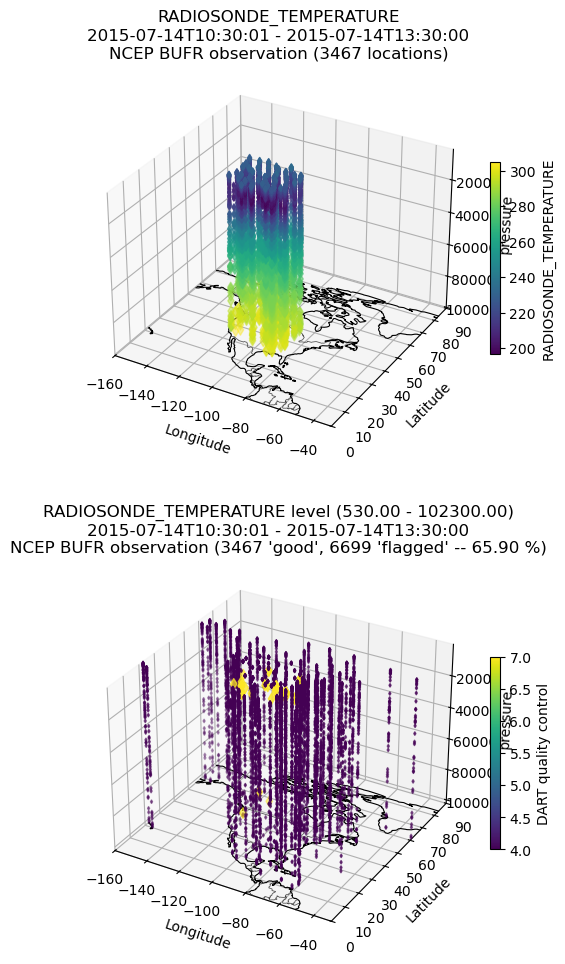

In [2]:
fname = '/gpfs/research/chipilskigroup/stephen_asare/output2/2015071412/obs_epoch_001.nc'
ObsTypeString = 'RADIOSONDE_TEMPERATURE'
region = [200, 330, 0, 90, -np.inf, np.inf]
CopyString = 'NCEP BUFR observation'
QCString = 'DART quality control'
maxQC = 2
verbose = 0
twoup = 1
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=0, twoup=1)

DART quality control is QC copy   2


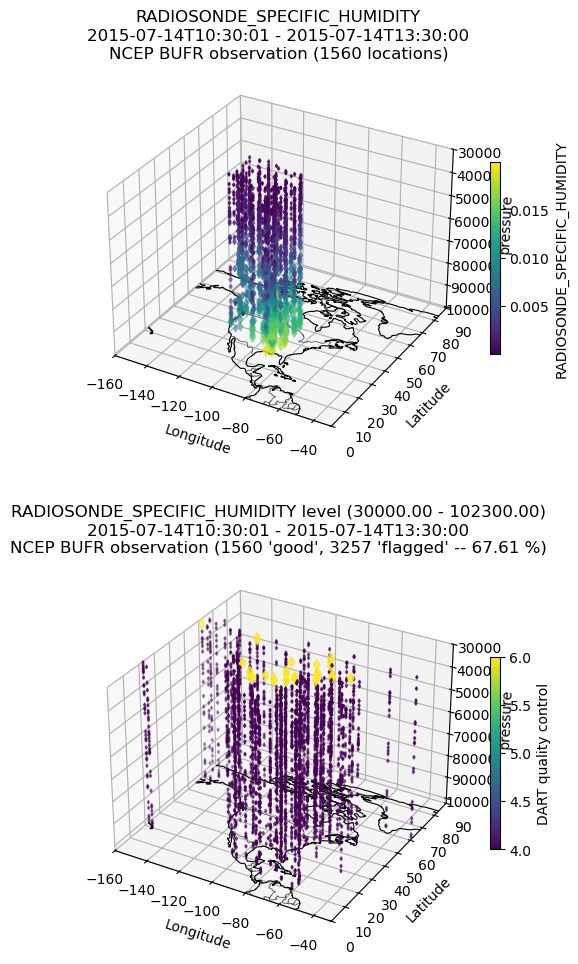

In [3]:
fname = '/gpfs/research/chipilskigroup/stephen_asare/output2/2015071412/obs_epoch_001.nc'
ObsTypeString = 'RADIOSONDE_SPECIFIC_HUMIDITY'
region = [200, 330, 0, 90, -np.inf, np.inf]
CopyString = 'NCEP BUFR observation'
QCString = 'DART quality control'
maxQC = 2
verbose = 1
twoup = 1
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=0, twoup=1)

In [4]:
from __future__ import annotations

import os
import re
from dataclasses import dataclass
from datetime import datetime, timedelta
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
from netCDF4 import Dataset, chartostring

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.backends.backend_pdf import PdfPages


# ======================================================================================
# NetCDF helpers (no guessing, deterministic string decoding)
# ======================================================================================

def nc_var_exists(fname: str, varname: str) -> Tuple[bool, Optional[str]]:
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")
    key = str(varname).strip()
    with Dataset(fname, "r") as ds:
        present = key in ds.variables
    return present, (key if present else None)


def nc_read_att(fname: str, varid: str, attname: str) -> Any:
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")
    att = str(attname).strip()
    with Dataset(fname, "r") as ds:
        if varid == "/":
            return ds.getncattr(att) if att in ds.ncattrs() else None
        v = ds.variables.get(varid, None)
        if v is None:
            return None
        return v.getncattr(att) if att in v.ncattrs() else None


def nc_dim_info(fname: str, dimname: str) -> Tuple[Optional[int], Optional[str]]:
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")
    key = str(dimname).strip()
    with Dataset(fname, "r") as ds:
        if key in ds.dimensions:
            return len(ds.dimensions[key]), key
    return None, None


def _read_nc_string_list(fname: str, varname: str) -> list[str]:
    """
    Read DART-style metadata vars (QCMetaData, CopyMetaData, ObsTypesMetaData)
    using netCDF dimension order (deterministic, no heuristic).
    """
    with Dataset(fname, "r") as ds:
        v = ds.variables[varname]
        raw = np.array(v[:])

        # vlen strings
        if raw.ndim == 1 and raw.dtype.kind in ("S", "U"):
            out = []
            for x in raw:
                if isinstance(x, (bytes, np.bytes_)):
                    out.append(x.decode(errors="ignore").replace("\x00", "").strip())
                else:
                    out.append(str(x).replace("\x00", "").strip())
            return out

        if raw.ndim != 2:
            raise ValueError(f"{varname} unexpected shape {raw.shape} dims={v.dimensions}")

        if raw.dtype.kind == "U":
            raw = raw.astype("S1")

        dims = v.dimensions
        if "stringlength" in dims and dims.index("stringlength") == 0:
            raw = raw.T

        sarr = chartostring(raw)
        return [str(s).replace("\x00", "").strip() for s in np.array(sarr).tolist()]


def get_copy_index(fname: str,
                   copystring: str,
                   *,
                   context: str = "CopyString",
                   fatal: bool = True,
                   verbose: bool = False) -> int:
    """
    MATLAB get_copy_index returns 1-based. Python returns 0-based for indexing.
    """
    copy_meta = _read_nc_string_list(fname, "CopyMetaData")

    def norm(s: str) -> str:
        return "".join(ch for ch in s.replace("\x00", "") if not ch.isspace())

    target = norm(copystring)
    idx = -1
    for i, md in enumerate(copy_meta):
        if norm(md) == target:
            idx = i

    if idx < 0 and fatal:
        errorstring = f'\nERROR: "{copystring.strip()}" is not a valid CopyMetaData value for file {fname}\n'
        msgstring = f'valid CopyMetaData values for "{context}" are'
        for md in copy_meta:
            msgstring += f"\n{md}"
        raise ValueError(f"{errorstring}\n{msgstring}")

    if verbose and idx >= 0:
        print(f'{copystring} is CopyMetaData index {idx+1:3d}')

    return idx


def nc_var_dims(ncfname: str, varname: str) -> Tuple[List[str], List[int]]:
    """
    Returns dimension names and sizes for a variable.
    """
    present, _ = nc_var_exists(ncfname, varname)
    if not present:
        raise ValueError(f"{ncfname} does not have a {varname} variable.")

    with Dataset(ncfname, "r") as ds:
        v = ds.variables[varname]
        dimnames = list(v.dimensions)
        dimsizes = list(v.shape)
    return dimnames, dimsizes


# ======================================================================================
# Time conversion (MATLAB datenum equivalent behavior but plotted with matplotlib dates)
# ======================================================================================

_TIME_UNITS_RE = re.compile(
    r"^\s*(\w+)\s+since\s+(\d{4})[-/](\d{1,2})[-/](\d{1,2})(?:[ T](\d{1,2}):(\d{1,2})(?::(\d{1,2}))?)?\s*$",
    re.IGNORECASE
)

def _parse_time_origin(timeunits: str) -> datetime:
    m = _TIME_UNITS_RE.match(timeunits or "")
    if not m:
        raise ValueError(f"Unrecognized time units: {timeunits!r}")
    _, yyyy, mm, dd, HH, MM, SS = m.groups()
    yyyy = int(yyyy); mm = int(mm); dd = int(dd)
    HH = int(HH) if HH is not None else 0
    MM = int(MM) if MM is not None else 0
    SS = int(SS) if SS is not None else 0
    return datetime(yyyy, mm, dd, HH, MM, SS)

def _to_datetimes_days(values: np.ndarray, units: str) -> np.ndarray:
    """
    Convert numeric time values to Python datetimes assuming CF-like 'days since ...'
    """
    units = str(units or "")
    if not units.lower().strip().startswith("days since"):
        raise ValueError(f"Only 'days since ...' supported. units={units!r}")
    origin = _parse_time_origin(units)
    vals = np.asarray(values, dtype=float).ravel()
    out = [origin + timedelta(days=float(v)) for v in vals]
    return np.array(out, dtype=object)


# ======================================================================================
# Variable harvesting (get_varnames/get_varsNdims)
# ======================================================================================

def get_varnames(fname: str) -> List[str]:
    """
    MATLAB get_varnames: returns NON-coordinate variables.
    """
    with Dataset(fname, "r") as ds:
        # netCDF4 doesn't directly expose ncinfo-like struct; use variables and their dims.
        # We mimic MATLAB logic using dimensions and known reject list.
        reject = {
            "inputnml", "time_bounds", "region_names", "CopyMetaData",
            "MemberMetadata", "ObservationTypes"
        }

        all_vars = list(ds.variables.keys())
        good = []

        for vname in all_vars:
            if vname in reject:
                continue

            v = ds.variables[vname]
            rank = len(v.shape)

            dimname = v.dimensions[0] if rank == 1 and len(v.dimensions) == 1 else None
            if dimname is not None and vname == dimname:
                continue

            good.append(vname)

    if not good:
        raise ValueError(f"There are only coordinate variables in {fname}")

    return good


def get_varsNdims(fname: str) -> Tuple[List[str], List[str]]:
    """
    MATLAB get_varsNdims: returns variable names and concatenated dimension-name strings.
    """
    allvarnames = get_varnames(fname)
    y = []
    ydims = []

    with Dataset(fname, "r") as ds:
        for varname in allvarnames:
            v = ds.variables[varname]
            dimnames = list(v.dimensions)
            y.append(varname)
            ydims.append(" ".join(dimnames))

    return y, ydims


# ======================================================================================
# Figure layout (set_obsdiag_figure)
# ======================================================================================

def set_obsdiag_figure(orientation: str, *, numexp: int = 1) -> Dict[str, Any]:
    """
    Return a dict equivalent to MATLAB figdata struct.
    """
    orientation_in = orientation.lower()
    if orientation_in.startswith("tall"):
        orientation = "tall"
        position = [0.15, 0.12, 0.7, 0.75]
        if numexp > 1:
            ybot = 0.06 + numexp * 0.035
            ytop = 0.125
            dy = 1.0 - ytop - ybot
            position = [0.15, ybot, 0.7, dy]
    else:
        orientation = "landscape"
        position = [0.10, 0.15, 0.8, 0.7]
        if numexp > 1:
            ybot = 0.06 + numexp * 0.075
            ytop = 0.125
            dy = 1.0 - ytop - ybot
            position = [0.10, ybot, 0.8, dy]

    figdata = {
        "expcolors":  ["k", "b", "m", "g", "c", "y", "r"],
        "expsymbols": ["o", "s", "d", "p", "h", "s", "*"],
        "prpolines":  ["-", "--"],
        "position": position,
        "fontsize": 16,
        "orientation": orientation,
        "linewidth": 2.5,
        "obs_color": (215/255, 10/255, 83/255),
        "ges_color": (0/255, 128/255, 0/255),
        "anl_color": (0/255, 0/255, 255/255),
        "rmse_color": (0/255, 0/255, 0/255),
        "copy_color": (0/255, 128/255, 128/255),
        "obs_marker": "o",
        "ges_marker": "*",
        "anl_marker": "d",
        "marker1": "o",
        "marker2": "s",
        "ges_linestyle": "-",
        "anl_linestyle": "-",
        "dashed": "--",
        "solid": "-",
        # runtime-set:
        "MarkerSize": 12,
        "DateForm": "default",
    }
    return figdata


# ======================================================================================
# NetCDF slicing (GetNCindices)
# ======================================================================================

def _is_dimension_cartesian(ncfname: str, dimname: str) -> Tuple[int, int, Optional[str]]:
    """
    Helper for GetNCindices: check if variable named dimname has attribute cartesian_axis.
    Returns (len, status, value)
    """
    with Dataset(ncfname, "r") as ds:
        if dimname not in ds.variables:
            return 0, 0, None
        v = ds.variables[dimname]
        if "cartesian_axis" in v.ncattrs():
            val = v.getncattr("cartesian_axis")
            # len is size of coordinate variable
            return int(v.size), 1, str(val)
    return 0, 0, None


def GetNCindices(pinfo: Dict[str, Any], whichfile: str, varname: str) -> Tuple[List[int], List[int]]:
    """
    MATLAB GetNCindices returns (start,count) in 1-based indexing for ncread.
    We return python-friendly (start,count) still in 1-based here, and convert later.
    """
    whichfile = whichfile.lower()
    if whichfile == "prior":
        fname = pinfo["prior_file"]
    elif whichfile == "posterior":
        fname = pinfo["posterior_file"]
    elif whichfile == "truth":
        fname = pinfo["truth_file"]
    elif whichfile == "diagn":
        fname = pinfo["diagn_file"]
    else:
        fname = pinfo["fname"]

    if not os.path.isfile(fname):
        raise FileNotFoundError(f"{fname} does not exist.")

    # Default full extents (Inf equivalent -> count=-1 later)
    lat1, latN = 1, np.inf
    lon1, lonN = 1, np.inf
    time1, timeN = 1, np.inf
    copy1, copyN = 1, np.inf
    member1, memberN = 1, np.inf
    level1, levelN = 1, np.inf
    state1, stateN = 1, np.inf
    region1, regionN = 1, np.inf
    cell1, cellN = 1, np.inf
    column1, columnN = 1, np.inf
    pft1, pftN = 1, np.inf
    rankbin1, rankbinN = 1, np.inf
    bounds1, boundsN = 1, np.inf
    obstypes1, obstypesN = 1, np.inf

    # Apply subsetting if present
    if "timeindex" in pinfo: time1, timeN = int(pinfo["timeindex"]), 1
    if "tindex1" in pinfo:   time1 = int(pinfo["tindex1"])
    if "tcount" in pinfo:    timeN = int(pinfo["tcount"])

    if "levelindex" in pinfo: level1, levelN = int(pinfo["levelindex"]), 1
    if "level1" in pinfo:     level1 = int(pinfo["level1"])
    if "levelcount" in pinfo: levelN = int(pinfo["levelcount"])

    if "latindex" in pinfo: lat1, latN = int(pinfo["latindex"]), 1
    if "lat1" in pinfo:     lat1 = int(pinfo["lat1"])
    if "latcount" in pinfo: latN = int(pinfo["latcount"])

    if "lonindex" in pinfo: lon1, lonN = int(pinfo["lonindex"]), 1
    if "lon1" in pinfo:     lon1 = int(pinfo["lon1"])
    if "loncount" in pinfo: lonN = int(pinfo["loncount"])

    if "stateindex" in pinfo: state1, stateN = int(pinfo["stateindex"]), 1
    if "state1" in pinfo:     state1 = int(pinfo["state1"])
    if "statecount" in pinfo: stateN = int(pinfo["statecount"])

    if "copyindex" in pinfo: copy1, copyN = int(pinfo["copyindex"]), 1
    if "copy1" in pinfo:     copy1 = int(pinfo["copy1"])
    if "copycount" in pinfo: copyN = int(pinfo["copycount"])

    if "memberindex" in pinfo: member1, memberN = int(pinfo["memberindex"]), 1
    if "member1" in pinfo:     member1 = int(pinfo["member1"])
    if "membercount" in pinfo: memberN = int(pinfo["membercount"])

    if "regionindex" in pinfo: region1, regionN = int(pinfo["regionindex"]), 1
    if "region1" in pinfo:     region1 = int(pinfo["region1"])
    if "regioncount" in pinfo: regionN = int(pinfo["regioncount"])

    if "cellindex" in pinfo: cell1, cellN = int(pinfo["cellindex"]), 1
    if "cell1" in pinfo:     cell1 = int(pinfo["cell1"])
    if "cellcount" in pinfo: cellN = int(pinfo["cellcount"])

    if "columnindex" in pinfo: column1, columnN = int(pinfo["columnindex"]), 1
    if "column1" in pinfo:     column1 = int(pinfo["column1"])
    if "columncount" in pinfo: columnN = int(pinfo["columncount"])

    if "pftindex" in pinfo: pft1, pftN = int(pinfo["pftindex"]), 1
    if "pft1" in pinfo:     pft1 = int(pinfo["pft1"])
    if "pftcount" in pinfo: pftN = int(pinfo["pftcount"])

    if "rankbinindex" in pinfo: rankbin1, rankbinN = int(pinfo["rankbinindex"]), 1
    if "rankbin1" in pinfo:      rankbin1 = int(pinfo["rankbin1"])
    if "rankbincount" in pinfo:  rankbinN = int(pinfo["rankbincount"])

    if "boundsindex" in pinfo: bounds1, boundsN = int(pinfo["boundsindex"]), 1
    if "bounds1" in pinfo:     bounds1 = int(pinfo["bounds1"])
    if "boundscount" in pinfo: boundsN = int(pinfo["boundscount"])

    if "obstypesindex" in pinfo: obstypes1, obstypesN = int(pinfo["obstypesindex"]), 1
    if "obstypes1" in pinfo:      obstypes1 = int(pinfo["obstypes1"])
    if "obstypescount" in pinfo:  obstypesN = int(pinfo["obstypescount"])

    with Dataset(fname, "r") as ds:
        v = ds.variables[varname]
        dims = list(v.dimensions)

    start = [0] * len(dims)
    count = [0] * len(dims)

    for i, dimname in enumerate(dims):
        _, status, value = _is_dimension_cartesian(fname, dimname)
        dname = value if status > 0 and value is not None else dimname
        dname_l = dname.lower()

        # emulate MATLAB switch on first 4 chars when possible
        key4 = dname_l[:4] if len(dname_l) >= 4 else dname_l

        if len(dname_l) >= 4:
            if key4 == "time":
                start[i], count[i] = time1, timeN
            elif key4 == "copy":
                start[i], count[i] = copy1, copyN
            elif key4 == "memb":
                start[i], count[i] = member1, memberN
            elif key4 in {"surf", "unde", "hlev", "mlev", "plev", "heig", "leve", "bott",
                          "ilev", "nver", "levt", "levs", "dept"}:
                start[i], count[i] = level1, levelN
            elif key4 in {"tmpj", "sout", "slat", "iyrt"}:
                start[i], count[i] = lat1, latN
            elif key4 in {"tmpi", "west", "slon", "ixrt"}:
                start[i], count[i] = lon1, lonN
            elif key4 in {"stat", "xloc", "yloc", "loca"}:
                start[i], count[i] = state1, stateN
            elif key4 == "regi":
                start[i], count[i] = region1, regionN
            elif key4 == "ncel":
                start[i], count[i] = cell1, cellN
            elif key4 == "colu":
                start[i], count[i] = column1, columnN
            elif key4 == "rank":
                start[i], count[i] = rankbin1, rankbinN
            elif key4 == "boun":
                start[i], count[i] = bounds1, boundsN
            elif key4 == "obst":
                start[i], count[i] = obstypes1, obstypesN
            else:
                # unknown coordinate type; preserve full span
                start[i], count[i] = 1, np.inf
        else:
            # short names fallbacks
            if dname_l == "t":
                start[i], count[i] = time1, timeN
            elif dname_l in {"lev", "z", "k"}:
                start[i], count[i] = level1, levelN
            elif dname_l in {"lat", "y", "iy", "j"}:
                start[i], count[i] = lat1, latN
            elif dname_l in {"lon", "x", "ix", "i"}:
                start[i], count[i] = lon1, lonN
            elif dname_l == "pft":
                start[i], count[i] = pft1, pftN
            else:
                start[i], count[i] = 1, np.inf

    # MATLAB uses -1 for Inf in count in our python slicing layer
    count = [(-1 if (c is np.inf) else int(c)) for c in count]
    start = [int(s) for s in start]
    return start, count


def _ncread_slice(fname: str, varname: str, start: Sequence[int], count: Sequence[int]) -> np.ndarray:
    """
    MATLAB ncread(fname,varname,start,count) where start is 1-based and count=-1 means Inf.
    """
    with Dataset(fname, "r") as ds:
        v = ds.variables[varname]
        nd = len(v.dimensions)
        if len(start) != nd or len(count) != nd:
            raise ValueError("start/count rank mismatch for variable")

        slices = []
        for s, c, dimlen in zip(start, count, v.shape):
            s0 = max(int(s) - 1, 0)
            if c == -1:
                slices.append(slice(s0, None))
            else:
                slices.append(slice(s0, s0 + int(c)))
        return np.array(v[tuple(slices)])


# ======================================================================================
# Obs_diag static data (read_obsdiag_staticdata)
# ======================================================================================

def read_obsdiag_staticdata(fname: str, copy: str) -> Dict[str, Any]:
    plotdat: Dict[str, Any] = {"fname": fname, "copystring": copy}

    with Dataset(fname, "r") as ds:
        plotdat["bincenters_raw"] = np.array(ds.variables["time"][:], dtype=float)
        plotdat["binedges_raw"] = np.array(ds.variables["time_bounds"][:], dtype=float)

    # optional vertical coords
    def local_ncread(vn: str):
        present, _ = nc_var_exists(fname, vn)
        if present:
            with Dataset(fname, "r") as ds:
                return np.array(ds.variables[vn][:])
        return np.array([])

    plotdat["mlevel"] = local_ncread("mlevel")
    plotdat["plevel"] = local_ncread("plevel")
    plotdat["plevel_edges"] = local_ncread("plevel_edges")
    plotdat["hlevel"] = local_ncread("hlevel")
    plotdat["hlevel_edges"] = local_ncread("hlevel_edges")

    plotdat["ncopies"], _ = nc_dim_info(fname, "copy")
    plotdat["nregions"], _ = nc_dim_info(fname, "region")

    # region_names is char array
    with Dataset(fname, "r") as ds:
        rn = np.array(ds.variables["region_names"][:])
    plotdat["region_names"] = _read_nc_string_list(fname, "region_names") if "region_names" in Dataset(fname).variables else []
    # above line is safe but Dataset(fname) opens file again; avoid in production.
    # For DART obs_diag, region_names usually is (region, stringlength) char:
    try:
        with Dataset(fname, "r") as ds:
            v = ds.variables["region_names"]
            raw = np.array(v[:])
        if raw.ndim == 2:
            plotdat["region_names"] = [str(s).strip() for s in chartostring(raw if v.dimensions.index("stringlength") == 1 else raw.T)]
        else:
            plotdat["region_names"] = [str(x).strip() for x in raw.tolist()]
    except Exception:
        pass

    plotdat["dimensionality"] = nc_read_att(fname, "/", "LocationRank")
    plotdat["binseparation"] = nc_read_att(fname, "/", "bin_separation")
    plotdat["binwidth"] = nc_read_att(fname, "/", "bin_width")
    plotdat["lonlim1"] = nc_read_att(fname, "/", "lonlim1")
    plotdat["lonlim2"] = nc_read_att(fname, "/", "lonlim2")
    plotdat["latlim1"] = nc_read_att(fname, "/", "latlim1")
    plotdat["latlim2"] = nc_read_att(fname, "/", "latlim2")
    plotdat["biasconv"] = nc_read_att(fname, "/", "bias_convention")

    plotdat["copyindex"] = get_copy_index(fname, copy)
    plotdat["rmseindex"] = get_copy_index(fname, "rmse")
    plotdat["biasindex"] = get_copy_index(fname, "bias")

    # Time conversion (days since origin -> datetimes)
    time_to_skip = nc_read_att(fname, "/", "time_to_skip")
    timeunits = nc_read_att(fname, "time", "units")

    bincenters_dt = _to_datetimes_days(plotdat["bincenters_raw"], str(timeunits))
    binedges_dt = _to_datetimes_days(plotdat["binedges_raw"].ravel(), str(timeunits)).reshape(plotdat["binedges_raw"].shape)

    # MATLAB computes datenum offsets; in matplotlib we use date2num
    plotdat["bincenters_dt"] = bincenters_dt
    plotdat["binedges_dt"] = binedges_dt
    plotdat["bincenters_num"] = mdates.date2num(bincenters_dt.tolist())
    plotdat["binedges_num"] = mdates.date2num(binedges_dt.tolist())

    plotdat["Nbins"] = int(len(plotdat["bincenters_num"]))

    # toff = first edge + iskip
    iskip_days = 0.0
    if time_to_skip is None or (isinstance(time_to_skip, (list, tuple, np.ndarray)) and len(np.asarray(time_to_skip).ravel()) == 0):
        iskip_days = 0.0
    else:
        tts = np.asarray(time_to_skip).ravel()
        if len(tts) == 6:
            skip_seconds = float(tts[3]) * 3600.0 + float(tts[4]) * 60.0 + float(tts[5])
            iskip_days = float(tts[2]) + skip_seconds / 86400.0
        else:
            raise ValueError("time_to_skip variable has unusual length. Should be either 0 or 6.")

    plotdat["toff"] = float(plotdat["binedges_num"][0, 0]) + iskip_days
    plotdat["timespan"] = f"{mdates.num2date(plotdat['toff']).strftime('%Y-%m-%d %H:%M:%S')} through {mdates.num2date(np.max(plotdat['binedges_num'])).strftime('%Y-%m-%d %H:%M:%S')}"
    return plotdat


# ======================================================================================
# QC harvesting (get_qc_values)
# ======================================================================================

def get_qc_values(fname: str,
                  varname: str,
                  *,
                  regionindex: Optional[int] = None,
                  levelindex: Optional[int] = None,
                  timeindex: Optional[int] = None,
                  verbose: bool = False,
                  fatal: bool = True) -> Dict[str, Any]:

    myinfo = {"diagn_file": fname}
    if regionindex is not None:
        myinfo["regionindex"] = int(regionindex)
    if levelindex is not None:
        myinfo["levelindex"] = int(levelindex)
    if timeindex is not None:
        myinfo["timeindex"] = int(timeindex)

    qcvalues: Dict[str, Any] = {"fname": fname, "varname": varname}

    myinfo["copyindex"] = get_copy_index(fname, "Nposs")
    start, count = GetNCindices(myinfo, "diagn", varname)
    nposs = _ncread_slice(fname, varname, start, count)

    myinfo["copyindex"] = get_copy_index(fname, "Nused")
    start, count = GetNCindices(myinfo, "diagn", varname)
    nused = _ncread_slice(fname, varname, start, count)

    # read N_DARTqc_0..8 if present
    Nqc = {}
    for qc in range(0, 9):
        try:
            myinfo["copyindex"] = get_copy_index(fname, f"N_DARTqc_{qc}", fatal=fatal, verbose=False)
        except Exception:
            myinfo["copyindex"] = -1

        if myinfo["copyindex"] >= 0:
            start, count = GetNCindices(myinfo, "diagn", varname)
            Nqc[qc] = _ncread_slice(fname, varname, start, count)
        else:
            Nqc[qc] = 0.0

    # ensure arrays
    for k in list(Nqc.keys()):
        Nqc[k] = np.asarray(Nqc[k])

    qcvalues["Nqc0"] = Nqc[0]
    qcvalues["Nqc1"] = Nqc[1]
    qcvalues["Nqc2"] = Nqc[2]
    qcvalues["Nqc3"] = Nqc[3]
    qcvalues["Nqc4"] = Nqc[4]
    qcvalues["Nqc5"] = Nqc[5]
    qcvalues["Nqc6"] = Nqc[6]
    qcvalues["Nqc7"] = Nqc[7]
    qcvalues["Nqc8"] = Nqc[8]

    qcvalues["nposs"] = np.asarray(nposs) - np.asarray(qcvalues["Nqc5"]) - np.asarray(qcvalues["Nqc6"])
    qcvalues["nused"] = np.asarray(nused)
    qcvalues["num_evaluated"] = np.asarray(qcvalues["Nqc1"]) + np.asarray(qcvalues["Nqc3"])

    if not verbose:
        return qcvalues

    # verbose prints (optional)
    print(f"\n{varname}")
    for qc in range(0, 9):
        arr = qcvalues.get(f"Nqc{qc}", None)
        if arr is not None:
            print(f"DART QC == {qc}, n = {int(np.sum(arr))}")

    return qcvalues


# ======================================================================================
# Plot formatting helpers (set_time_axis / matchingYticks / matchingXticks)
# ======================================================================================

def set_time_axis(ax: plt.Axes, bincenters_num: np.ndarray, DateForm: str = "default") -> str:
    """
    Easiest appropriate: AutoDateLocator + ConciseDateFormatter.
    Returns a label string like 'YYYY-MM-DD start' or 'days'.
    """
    x0 = float(np.nanmin(bincenters_num))
    x1 = float(np.nanmax(bincenters_num))
    ndays = (x1 - x0) + 1.0

    if x0 > 1000:  # same intent as MATLAB: datenum-like values
        locator = mdates.AutoDateLocator()
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        start_str = mdates.num2date(x0).strftime("%Y-%m-%d")
        return f"{start_str} start"

    return "days"


def matchingYticks(ax1: plt.Axes, ax2: plt.Axes) -> None:
    """
    Python port of MATLAB matchingYticks(ax1,ax2).
    """
    Dlimits = ax1.get_ylim()
    DYticks = ax1.get_yticks()
    nYticks = len(DYticks)
    ylimits = list(ax2.get_ylim())

    yrange = (ylimits[1] - ylimits[0])
    if yrange <= 0:
        return

    yrange_log = np.log10(yrange)
    yrange_magnitude = np.floor(yrange_log)
    yrange_span = 10 ** (yrange_log - yrange_magnitude)

    delta = 1.0e-14
    if (nYticks - 1 - yrange_span) > delta:
        yrange_span *= 10
        yrange_magnitude -= 1

    yrange_tick_size = np.ceil((yrange_span - delta) / max(nYticks - 1, 1)) * (10 ** yrange_magnitude)
    yrange_tick_size = max(float(yrange_tick_size), 1.0)

    yticks0 = np.floor(ylimits[0] / yrange_tick_size - 1) * yrange_tick_size
    iticks = np.arange(1, nYticks + 1)
    yticks = yticks0 + yrange_tick_size * iticks

    if nYticks >= 2:
        D_tick_size = DYticks[1] - DYticks[0]
    else:
        D_tick_size = max(Dlimits[1] - Dlimits[0], 1.0)

    ylimits[0] = yticks[0] - yrange_tick_size * ((DYticks[0] - Dlimits[0]) / D_tick_size)
    ylimits[1] = yticks[-1] + yrange_tick_size * ((Dlimits[1] - DYticks[-1]) / D_tick_size)

    newticklabels = [f"{v:.1f}".rstrip("0").rstrip(".") for v in np.round(10 * yticks) / 10]

    ax2.set_yticks(yticks)
    ax2.set_yticklabels(newticklabels)
    ax2.set_ylim(ylimits)

    # ensure overlay stays aligned
    ax1.set_position(ax2.get_position())
    ax1.grid(True)


# def matchingXticks(ax1, ax2):
def matchingXticks(ax1: plt.Axes, ax2: plt.Axes) -> float:
    """
    Match tick *count* on ax2 to ax1 while keeping ax2's own x-limits.
    Returns a power-of-10 scale factor for the axis label (Matlab-like).
    """
    base_ticks = ax1.get_xticks()
    nt = len(base_ticks)
    if nt < 2:
        return 1.0

    x0, x1 = ax2.get_xlim()
    span = max(x1 - x0, 1.0)

    mag = np.floor(np.log10(span))
    xscale = 10.0 ** mag

    step = np.ceil((span / (nt - 1)) / xscale) * xscale
    step = max(step, 1.0)

    t0 = np.floor(x0 / step) * step
    ticks = t0 + step * np.arange(0, nt + 4)
    ticks = ticks[(ticks >= x0) & (ticks <= x1)]

    if len(ticks) < 2:
        ticks = np.linspace(x0, x1, nt)

    ax2.set_xticks(ticks)
    labels = np.round(np.asarray(ticks) / xscale, 1)
    ax2.set_xticklabels([f"{v:g}" for v in labels])

    return xscale

# ======================================================================================
# Core plot logic from plot_evolution.m (myplot + helpers)
# ======================================================================================

def ReturnBase(string1: str) -> str:
    for suf in ["_guess", "_analy", "_VPguess", "_VPanaly"]:
        k = string1.find(suf)
        if k > 0:
            return string1[:k]
    return ""


def FindTemporalVars(x: Dict[str, Any], verbose: bool = False) -> Tuple[List[str], List[str]]:
    if not ("allvarnames" in x and "allvardims" in x):
        raise ValueError("no 'allvarnames' and 'allvardims' components")

    basenames = []
    basedims = []
    for name, dims in zip(x["allvarnames"], x["allvardims"]):
        if "time" in dims:
            base = ReturnBase(name)
            if base:
                basenames.append(base)
                basedims.append(dims)

    # unique preserving first occurrence
    seen = {}
    for b, d in zip(basenames, basedims):
        if b not in seen:
            seen[b] = d

    y = list(seen.keys())
    ydims = [seen[k] for k in y]
    if verbose:
        for i, b in enumerate(y, 1):
            print(f"{i:3d} is {b}")
    return y, ydims


def FindRange(y: Dict[str, Any]) -> List[float]:
    bob = np.concatenate([
        np.asarray(y["ges_copy"]).ravel(),
        np.asarray(y["anl_copy"]).ravel()
    ])
    bob = bob[np.isfinite(bob)]
    if bob.size == 0:
        return [0.0, 1.0]

    ymin = float(np.min(bob))
    ymax = float(np.max(bob))

    if ymax > 1.0:
        ymin = float(np.floor(ymin))
        ymax = float(np.ceil(ymax))
    elif ymax < 0.0 and str(y.get("copystring", "")).lower() == "bias":
        ymax = 0.0

    return [min(ymin, 0.0), ymax]


def plot_quantity(phase: str, plotdat: Dict[str, Any], ax: plt.Axes, figuredata: Dict[str, Any]) -> Tuple[Any, str]:
    phase = phase.lower()

    if phase == "prior":
        data = np.squeeze(plotdat["ges_copy"][plotdat["region"] - 1, ...])
        Nused = np.squeeze(plotdat["ges_Nused"][plotdat["region"] - 1, ...])
        color = figuredata["ges_color"]
        marker = figuredata["marker1"]
        linestyle = figuredata["solid"]
        linewidth = figuredata["linewidth"]
        string1 = "forecast:"
    elif phase == "posterior":
        data = np.squeeze(plotdat["anl_copy"][plotdat["region"] - 1, ...])
        Nused = np.squeeze(plotdat["anl_Nused"][plotdat["region"] - 1, ...])
        color = figuredata["anl_color"]
        marker = figuredata["marker2"]
        linestyle = figuredata["solid"]
        linewidth = figuredata["linewidth"]
        string1 = "analysis:"
    else:
        raise ValueError(f"phase ({phase}) not supported")

    if np.sum(Nused) > 1:
        data_mean = float(np.mean(data[np.isfinite(data)])) if np.any(np.isfinite(data)) else np.nan
        legstr = f"{string1} mean = {data_mean:.5g}"
    else:
        legstr = " "

    h, = ax.plot(plotdat["bincenters_num"], data,
                 linestyle=linestyle,
                 linewidth=linewidth,
                 color=color,
                 marker=marker,
                 markersize=figuredata["MarkerSize"],
                 markerfacecolor=color)
    return h, legstr


def BottomAnnotation(fig: plt.Figure, main: Dict[str, Any]) -> None:
    # MATLAB uses an extra subplot; easiest is figure text.
    fname = main["fname"]
    full = fname if fname.startswith("/") else os.path.join(os.getcwd(), fname)
    fig.text(0.5, 0.02, f"data file: {full}", ha="center", va="center", fontsize=8)

    if str(main.get("trusted", "")).lower() == "true":
        fig.text(0.5, 0.045, "TRUSTED OBSERVATION. Values include outlying obs.",
                 ha="center", va="center", fontsize=14)


def myplot(plotdat: Dict[str, Any], figuredata: Dict[str, Any], verbose: bool) -> None:
    fig = plt.gcf()

    ax1 = fig.add_axes(figuredata["position"])
    ax1.yaxis.set_label_position("left")
    ax1.yaxis.tick_left()
    ax1.tick_params(labelsize=figuredata["fontsize"])

    hprior, prior_legstr = plot_quantity("prior", plotdat, ax1, figuredata)

    ges_Nposs = np.squeeze(plotdat["ges_Nposs"][plotdat["region"] - 1, ...])
    ges_Nused = np.squeeze(plotdat["ges_Nused"][plotdat["region"] - 1, ...])
    anl_Nused = np.squeeze(plotdat["anl_Nused"][plotdat["region"] - 1, ...])
    anl_Ngood = float(np.sum(anl_Nused))

    handles = [hprior]
    labels = [prior_legstr]

    poste_legstr = ""
    if anl_Ngood > 0:
        hposte, poste_legstr = plot_quantity("posterior", plotdat, ax1, figuredata)
        handles.append(hposte)
        labels.append(poste_legstr)

    leg = ax1.legend(handles, labels, frameon=False, fontsize=figuredata["fontsize"])
    # (Matlab disables autoupdate; matplotlib does not autoupdate legends by default)

    if verbose:
        print(f"region {plotdat['region']} {plotdat['myvarname']} level {plotdat['mylevel']} "
              f"nobs_poss {int(np.sum(ges_Nposs))} prior {int(np.sum(ges_Nused))} poste {int(anl_Ngood)}")
        print(f"region {plotdat['region']} {plotdat['myvarname']} level {plotdat['mylevel']} "
              f"{prior_legstr} {poste_legstr}\n")

    ax1.set_xlim(np.min(plotdat["bincenters_num"]), np.max(plotdat["bincenters_num"]))
    ax1.set_ylim(plotdat["Yrange"][0], plotdat["Yrange"][1])

    # bias zeroline
    if str(plotdat["copystring"]).lower() == "bias":
        ax1.axhline(0.0, color=(200/255, 200/255, 200/255), linewidth=2.5)
        plotdat["ylabel"] = f"{plotdat['copystring']} ({plotdat.get('biasconv','')})"
    else:
        plotdat["ylabel"] = f"{plotdat['copystring']}"

    xlabelstring = set_time_axis(ax1, plotdat["bincenters_num"], figuredata.get("DateForm", "default"))
    ax1.set_xlabel(xlabelstring, fontsize=figuredata["fontsize"])
    ax1.set_ylabel(plotdat["ylabel"], fontsize=figuredata["fontsize"])

    ax1.set_title(f"{plotdat['myregion']}\n{plotdat['title']}",
                  fontsize=figuredata["fontsize"], fontweight="bold")

    BottomAnnotation(fig, plotdat)

    # observation count axis (overlay)
    ax2 = ax1.twinx()
    ax2.set_xlim(ax1.get_xlim())
    ax2.xaxis.set_ticks_position("top")
    ax2.xaxis.set_label_position("top")
    ax2.tick_params(axis="y", colors=figuredata["obs_color"])
    ax2.tick_params(axis="x", labelbottom=False, labeltop=False)

    # plot obs counts as markers (no lines)
    ax2.plot(plotdat["bincenters_num"], ges_Nposs, linestyle="none",
             color=figuredata["obs_color"], marker=figuredata["obs_marker"],
             markersize=figuredata["MarkerSize"])
    ax2.plot(plotdat["bincenters_num"], ges_Nused, linestyle="none",
             color=figuredata["obs_color"], marker=figuredata["ges_marker"],
             markersize=figuredata["MarkerSize"])
    if anl_Ngood > 0:
        ax2.plot(plotdat["bincenters_num"], anl_Nused, linestyle="none",
                 color=figuredata["obs_color"], marker=figuredata["anl_marker"],
                 markersize=figuredata["MarkerSize"])

    # make obs axis start at 0
    y0, y1 = ax2.get_ylim()
    ax2.set_ylim(0.0, y1)

    # match ticks/labels
    matchingYticks(ax1, ax2)

    if np.sum(plotdat["ges_Neval"]) > 0:
        string1 = f"# of obs: o=possible; *=evaluated{plotdat.get('post_string','')}"
    else:
        string1 = f"# of obs: o=possible; *=assimilated{plotdat.get('post_string','')}"
    ax2.set_ylabel(string1, fontsize=figuredata["fontsize"], color=figuredata["obs_color"])


# # ======================================================================================
# # Main: plot_evolution (Python translation)
# # ======================================================================================

# def plot_evolution(fname: str,
#                    copy: str,
#                    *,
#                    obsname: str = "none",
#                    verbose: bool = True,
#                    MarkerSize: int = 12,
#                    pause: bool = False,
#                    range: Sequence[float] = (np.nan, np.nan),
#                    level: int = -1,
#                    DateForm: str = "default") -> Dict[str, Any]:
#     """
#     Python translation of MATLAB plot_evolution.m.

#     Output: writes PDF pages per region:
#       '{obsname}_{copy}_evolution_region{iregion}.pdf' (multi-page: one page per level)
#     and writes a log file:
#       '{obsname}_{copy}_obscount.txt'
#     Returns plotdat from the last plotted variable/level/region.
#     """
#     if len(range) != 2:
#         raise ValueError("range must be length 2: [bottom top]")

#     if not os.path.isfile(fname):
#         raise FileNotFoundError(f"file/fname <{fname}> does not exist")

#     # Static metadata
#     plotdat = read_obsdiag_staticdata(fname, copy)

#     # Which variables
#     if obsname == "none":
#         allvarnames, allvardims = get_varsNdims(fname)
#         plotdat["allvarnames"] = allvarnames
#         plotdat["allvardims"] = allvardims
#         varnames, vardims = FindTemporalVars(plotdat, verbose=False)
#         plotdat["varnames"] = varnames
#         plotdat["vardims"] = vardims
#         plotdat["nvars"] = len(varnames)
#     else:
#         plotdat["varnames"] = [obsname]
#         plotdat["nvars"] = 1

#     figuredata = set_obsdiag_figure("landscape")
#     figuredata["MarkerSize"] = MarkerSize
#     figuredata["DateForm"] = DateForm
#     verbose_flag = bool(verbose)

#     for ivar in range(plotdat["nvars"]):
#         plotdat["myvarname"] = plotdat["varnames"][ivar]
#         plotdat["guessvar"] = f"{plotdat['myvarname']}_guess"
#         plotdat["analyvar"] = f"{plotdat['myvarname']}_analy"

#         # trusted attribute
#         trusted = nc_read_att(fname, plotdat["guessvar"], "TRUSTED")
#         plotdat["trusted"] = trusted if trusted is not None and str(trusted).strip() != "" else "NO"

#         # check QC summary presence
#         qcvalues = get_qc_values(fname, plotdat["guessvar"], fatal=False, verbose=False)
#         if np.sum(qcvalues["nposs"]) < 1:
#             print(f"no obs for {plotdat['myvarname']}...  skipping")
#             continue

#         dimnames, _ = nc_var_dims(fname, plotdat["guessvar"])

#         # Determine vertical levels to loop
#         if plotdat.get("dimensionality", None) == 1:
#             plotdat["varlevels"] = np.array([1.0])
#             plotdat["level"] = [1]
#             plotdat["level_units"] = ""
#         elif "surface" in str(dimnames[1]):
#             plotdat["varlevels"] = np.array([1.0])
#             plotdat["level"] = [1]
#             plotdat["level_units"] = "surface"
#         elif "undef" in str(dimnames[1]):
#             plotdat["varlevels"] = np.array([1.0])
#             plotdat["level"] = [1]
#             plotdat["level_units"] = "undefined"
#         else:
#             # read coordinate variable for dimnames[1]
#             with Dataset(fname, "r") as ds:
#                 plotdat["varlevels"] = np.array(ds.variables[dimnames[1]][:])
#             plotdat["level_units"] = nc_read_att(fname, dimnames[1], "units") or ""
#             nlevels = int(len(plotdat["varlevels"]))
#             if level < 0:
#                 plotdat["level"] = list(range(1, nlevels + 1))
#             elif 0 < level < nlevels:
#                 plotdat["level"] = [int(round(level))]
#             else:
#                 raise ValueError(f"valid level values are 1 <= {nlevels}\n{level} is not a valid level for {plotdat['guessvar']}")

#         # read whole variables
#         with Dataset(fname, "r") as ds:
#             guess = np.array(ds.variables[plotdat["guessvar"]][:])

#         # local_ncread analy
#         present, _ = nc_var_exists(fname, plotdat["analyvar"])
#         if present:
#             with Dataset(fname, "r") as ds:
#                 analy = np.array(ds.variables[plotdat["analyvar"]][:])
#         else:
#             analy = np.array([])
#         if analy.size == 0:
#             analy = np.array(guess, copy=True)
#             analy[:] = np.nan
#             has_posterior = False
#             plotdat["post_string"] = ""
#         else:
#             has_posterior = True
#             plotdat["post_string"] = "; ♦=posteriorOK"

#         # output files: one PDF per region
#         pdfs = []
#         psfname = []
#         for iregion in range(1, int(plotdat["nregions"]) + 1):
#             outpdf = f"{plotdat['myvarname']}_{plotdat['copystring']}_evolution_region{iregion}.pdf"
#             psfname.append(outpdf)
#             pdfs.append(PdfPages(outpdf))

#         # log file
#         lgfname = f"{plotdat['myvarname']}_{plotdat['copystring']}_obscount.txt"
#         with open(lgfname, "w", encoding="utf-8") as logfid:
#             logfid.write(lgfname + "\n")

#             for ilevel, lev_index in enumerate(plotdat["level"], start=1):
#                 priorQCs = get_qc_values(fname, plotdat["guessvar"],
#                                          levelindex=int(lev_index),
#                                          fatal=False,
#                                          verbose=verbose_flag)

#                 plotdat["mylevel"] = int(lev_index)
#                 plotdat["ges_Neval"] = priorQCs["num_evaluated"]
#                 plotdat["ges_Nposs"] = priorQCs["nposs"]
#                 plotdat["ges_Nused"] = priorQCs["nused"]

#                 # data arrays: guess(time, level, copy, region) in MATLAB
#                 # Here we assume same ordering as stored; use slicing exactly like MATLAB:
#                 plotdat["ges_copy"] = guess[:, plotdat["mylevel"] - 1, plotdat["copyindex"], :]
#                 plotdat["anl_copy"] = analy[:, plotdat["mylevel"] - 1, plotdat["copyindex"], :]

#                 if has_posterior:
#                     posteQCs = get_qc_values(fname, plotdat["analyvar"],
#                                              levelindex=int(plotdat["mylevel"]),
#                                              fatal=False,
#                                              verbose=verbose_flag)
#                     plotdat["anl_Nused"] = posteQCs["nused"]
#                     plotdat["anl_copy"] = analy[:, plotdat["mylevel"] - 1, plotdat["copyindex"], :]
#                 else:
#                     plotdat["anl_Nused"] = np.zeros_like(plotdat["ges_Nused"])
#                     plotdat["anl_copy"] = plotdat["ges_copy"]

#                 if np.isnan(range[0]):
#                     plotdat["Yrange"] = FindRange(plotdat)
#                 else:
#                     plotdat["Yrange"] = [float(range[0]), float(range[1])]

#                 # plot each region to its PDF as a new page
#                 for iregion in range(1, int(plotdat["nregions"]) + 1):
#                     fig = plt.figure()
#                     plotdat["region"] = iregion
#                     # region_names was decoded to list[str]
#                     if isinstance(plotdat.get("region_names", []), list) and len(plotdat["region_names"]) >= iregion:
#                         plotdat["myregion"] = str(plotdat["region_names"][iregion - 1]).strip()
#                     else:
#                         plotdat["myregion"] = f"region {iregion}"

#                     if not plotdat.get("level_units", ""):
#                         plotdat["title"] = plotdat["myvarname"]
#                     else:
#                         lvlval = float(plotdat["varlevels"][plotdat["mylevel"] - 1]) if plotdat["varlevels"].size else float(plotdat["mylevel"])
#                         plotdat["title"] = f"{plotdat['myvarname']} @ {lvlval} {plotdat['level_units']}"

#                     myplot(plotdat, figuredata, verbose_flag)
#                     pdfs[iregion - 1].savefig(fig)
#                     plt.close(fig)

#                     if pause:
#                         input("Pausing, press Enter to continue...")

#             # close PDFs
#         for pp in pdfs:
#             pp.close()

#     return plotdat

In [19]:
from __future__ import annotations

import os
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt

# REQUIREMENTS (must already exist from your previous translation):
#   - read_obsdiag_staticdata(fname, copy) -> plotdat dict
#   - get_varsNdims(fname) -> (allvarnames, allvardims)
#   - nc_var_dims(fname, varname) -> (dimnames, dimsizes)
#   - nc_read_att(fname, varname_or_slash, attname)
#   - nc_var_exists(fname, varname)
#   - get_qc_values(fname, varname, fatal=False, verbose=bool, ...) -> dict with nposs,nused,num_evaluated, etc.
#   - set_obsdiag_figure("tall") -> figuredata dict (position, colors, markers, etc.)
#   - matchingXticks(ax1, ax2) -> xscale
#
# AND netCDF reading:
#   - netCDF4.Dataset is available OR you provide your own local_ncread() wrapper.


def _local_ncread(fname: str, varname: str) -> np.ndarray:
    """MATLAB local_ncread: return variable array or empty array."""
    present, _ = nc_var_exists(fname, varname)
    if not present:
        return np.array([])
    from netCDF4 import Dataset
    with Dataset(fname, "r") as ds:
        return np.array(ds.variables[varname][:])


def ReturnBase_vertical(string1: str) -> str:
    """MATLAB ReturnBase() for vertical/profile naming."""
    for suf in ["_guess", "_analy", "_VPguess", "_VPanaly"]:
        k = string1.find(suf)
        if k > 0:
            return string1[:k]
    return ""


def FindVerticalVars(plotdat: Dict[str, Any], verbose: bool = False) -> Tuple[List[str], List[str]]:
    """
    MATLAB FindVerticalVars():
      - returns unique base variable names for variables WITHOUT 'time' in dims
      - only those with suffix _guess/_analy/_VPguess/_VPanaly
    """
    if not ("allvarnames" in plotdat and "allvardims" in plotdat):
        raise ValueError("Need plotdat['allvarnames'] and plotdat['allvardims']")

    basenames: List[str] = []
    basedims: List[str] = []

    for name, dims in zip(plotdat["allvarnames"], plotdat["allvardims"]):
        dimnames_lower = str(dims).lower()
        if "time" in dimnames_lower:
            continue
        # base = ReturnBase_vertical(str(name))
        base = ReturnBase_vertical(str(name))
        if base:
            # Only keep bases that have profile variables (_VPguess) in the file
            present, _ = nc_var_exists(plotdat["fname"], f"{base}_VPguess")
            if present:
                basenames.append(base)
                basedims.append(str(dims))


            

    # unique, preserve first occurrence
    seen = {}
    for b, d in zip(basenames, basedims):
        if b not in seen:
            seen[b] = d

    y = list(seen.keys())
    ydims = [seen[k] for k in y]

    if verbose:
        for i, b in enumerate(y, 1):
            print(f"{i:3d} is {b}")

    return y, ydims


def FindVerticalInfo(fname: str, varname: str) -> Tuple[np.ndarray, str, int, np.ndarray, List[float]]:
    """
    MATLAB FindVerticalInfo():
      - find dimension name containing 'level'
      - levels = ncread(coordvar)
      - units = ncreadatt(coordvar,'units')
      - edges = ncread(f"{coordvar}_edges")
      - Yrange = [min(edges), max(edges)]
    """
    from netCDF4 import Dataset

    with Dataset(fname, "r") as ds:
        if varname not in ds.variables:
            raise ValueError(f"{varname} not in {fname}")
        v = ds.variables[varname]
        dimnames = list(v.dimensions)

    leveldim = None
    for i, dn in enumerate(dimnames):
        if "level" in dn:
            leveldim = i
    if leveldim is None:
        raise ValueError(f"There is no level information for {varname} in {fname}")

    level_coord_name = dimnames[leveldim]

    with Dataset(fname, "r") as ds:
        levels = np.array(ds.variables[level_coord_name][:])
        # units attribute
        try:
            level_units = str(ds.variables[level_coord_name].getncattr("units"))
        except Exception:
            level_units = ""
        nlevels = int(ds.variables[level_coord_name].size)
        edgename = f"{level_coord_name}_edges"
        if edgename not in ds.variables:
            raise ValueError(f"Missing {edgename} in {fname}")
        level_edges = np.array(ds.variables[edgename][:])

    Yrange = [float(np.min(level_edges)), float(np.max(level_edges))]
    return levels, level_units, nlevels, level_edges, Yrange


def FindRange_profile(plotdat: Dict[str, Any]) -> List[float]:
    """
    MATLAB FindRange() for profile:
      bob = [ges_copy; ges_rmse; anl_copy; anl_rmse]
      produce "nice" range, bounded below by 0; ensure non-degenerate
    """
    bob = np.concatenate([
        np.asarray(plotdat["ges_copy"]).ravel(),
        np.asarray(plotdat["ges_rmse"]).ravel(),
        np.asarray(plotdat["anl_copy"]).ravel(),
        np.asarray(plotdat["anl_rmse"]).ravel(),
    ])
    bob = bob[np.isfinite(bob)]

    if bob.size == 0:
        return [0.0, 1.0]

    ymin = float(np.min(bob))
    ymax = float(np.max(bob))

    if ymax > 1.0:
        ymin = float(np.floor(ymin))
        ymax = float(np.ceil(ymax))

    if ymin == 0.0 and ymax == 0.0:
        ymax = 1.0
    if ymin == ymax:
        ymin = ymin - 0.1 * ymin
        ymax = ymax + 0.1 * ymax

    # MATLAB: sort([min([Yrange(1) 0]) Yrange(2)],'ascend')
    return sorted([min(ymin, 0.0), ymax])


def Stripes(ax: plt.Axes, x: Sequence[float], edges: np.ndarray, units: str) -> None:
    """
    MATLAB Stripes(x,edges,units):
      - draws alternating gray stripes between vertical edges.
      - also adjusts axis limits to add legend room for common units.
    """
    x = np.asarray(x, dtype=float)
    edges = np.asarray(edges, dtype=float)

    # seed axis limits (like MATLAB plotting invisible dots)
    ax.plot([np.min(x), np.max(x)], [np.min(edges), np.max(edges)], alpha=0.0)

    axlims = list(ax.axis())  # [xmin,xmax,ymin,ymax]
    legend_fraction = 0.22

    u = (units or "").lower()
    if u == "hpa":
        axlims[3] = float(np.max(edges))
        axlims[2] = float(np.min(edges)) - legend_fraction * (axlims[3] - float(np.min(edges)))
    elif u == "m":
        axlims[2] = float(np.min(edges))
        axlims[3] = float(np.max(edges)) + legend_fraction * (float(np.max(edges)) - axlims[2])

    ax.axis(axlims)

    xmin, xmax, ymin, ymax = axlims
    for i in range(0, len(edges) - 1, 2):
        y0 = edges[i]
        y1 = edges[i + 1]
        ax.fill([xmin, xmax, xmax, xmin], [y0, y0, y1, y1],
                color=(0.8, 0.8, 0.8), edgecolor="none", zorder=0)

    ax.grid(True)



def extract_profile_region_level(var: np.ndarray, dims: tuple[str, ...], copy_index: int) -> np.ndarray:
    """
    Returns (region, level) array from a profile variable with dims containing:
      - 'copy'
      - 'region'
      - exactly one vertical dim (anything else; we pick the one that's neither copy nor region)

    No guessing beyond those rules.
    """
    if "copy" not in dims or "region" not in dims:
        raise ValueError(f"Need 'copy' and 'region' in dims, got {dims}")

    # identify level dim: must be the remaining one
    other_dims = [d for d in dims if d not in ("copy", "region")]
    if len(other_dims) != 1:
        raise ValueError(f"Expected exactly one non-(copy,region) dim; got {other_dims} from {dims}")
    level_dim = other_dims[0]

    copy_ax = dims.index("copy")
    region_ax = dims.index("region")
    level_ax = dims.index(level_dim)

    # take the requested copy along the right axis
    arr = np.take(var, indices=copy_index, axis=copy_ax)

    # after take(), copy axis removed; rebuild remaining dims order
    rem_dims = [d for d in dims if d != "copy"]
    region_ax2 = rem_dims.index("region")
    level_ax2  = rem_dims.index(level_dim)

    # reorder to (region, level)
    arr = np.moveaxis(arr, [region_ax2, level_ax2], [0, 1])
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D (region, level), got shape {arr.shape} from dims {dims}")
    return arr



def plot_rmse_xxx_profile(fname: str,
                          copy: str,
                          *,
                          obsname: str = "none",
                          verbose: bool = True,
                          MarkerSize: int = 12,
                          pause: bool = False,
                          yrange: Sequence[float] = (np.nan, np.nan)) -> Dict[str, Any]:
    """
    Python translation of MATLAB plot_rmse_xxx_profile().

    Writes: '{var}_rmse_{copy}_profile_region{iregion}.pdf'
    Returns: plotdat (last plotted)
    """
    if len(yrange) != 2:
        raise ValueError("range must be length 2: [bottom top]")
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"file/fname <{fname}> does not exist")

    plotdat = read_obsdiag_staticdata(fname, copy)
    plotdat["xlabel"] = f"rmse and {copy}"

    # pick vars
    if obsname == "none":
        allvarnames, allvardims = get_varsNdims(fname)
        plotdat["allvarnames"] = allvarnames
        plotdat["allvardims"] = allvardims
        varnames, vardims = FindVerticalVars(plotdat, verbose=False)
        plotdat["varnames"] = varnames
        plotdat["vardims"] = vardims
        plotdat["nvars"] = len(varnames)
    else:
        plotdat["varnames"] = [obsname]
        plotdat["nvars"] = 1

    figuredata = set_obsdiag_figure("tall")
    figuredata["MarkerSize"] = MarkerSize
    import builtins
    for ivar in builtins.range(plotdat["nvars"]):
    # for ivar in range(plotdat["nvars"]):
        plotdat["myvarname"] = plotdat["varnames"][ivar]
        plotdat["guessvar"] = f"{plotdat['myvarname']}_VPguess"
        plotdat["analyvar"] = f"{plotdat['myvarname']}_VPanaly"

        trusted = nc_read_att(fname, plotdat["guessvar"], "TRUSTED")
        plotdat["trusted"] = trusted if trusted is not None and str(trusted).strip() != "" else "NO"

        dimnames, _ = nc_var_dims(fname, plotdat["guessvar"])

        # weed surface / undef (same check as MATLAB)
        if len(dimnames) >= 2 and ("surface" in dimnames[1]):
            # print(f"{plotdat['guessvar']} is a surface field.\nCannot display a surface field this way.\n")
            continue
        if len(dimnames) >= 2 and ("undef" in dimnames[1]):
            # print(f"{plotdat['guessvar']} has no vertical definition.\nCannot display this field this way.\n")
            continue

        levels, level_units, nlevels, level_edges, Yrange = FindVerticalInfo(fname, plotdat["guessvar"])
        plotdat["levels"] = np.asarray(levels)
        plotdat["level_units"] = level_units
        plotdat["nlevels"] = int(nlevels)
        plotdat["level_edges"] = np.asarray(level_edges)
        plotdat["Yrange"] = Yrange

        # YDir
        if plotdat["levels"][0] > plotdat["levels"][plotdat["nlevels"] - 1]:
            plotdat["YDir"] = "reverse"
        else:
            plotdat["YDir"] = "normal"

        # YTick (unique sorted levels)
        levels_sorted = np.sort(plotdat["levels"])
        plotdat["YTick"] = np.unique(levels_sorted)

        if len(plotdat["YTick"]) != len(plotdat["levels"]):
            raise ValueError("Duplicated values in levels array: rerun obs_diag with fixed input.nml")

        plotdat["level_edges"] = np.sort(plotdat["level_edges"])

        # # guess/analy arrays: guess(nregions,nlevels,ncopies)
        # from netCDF4 import Dataset
        # with Dataset(fname, "r") as ds:
        #     guess = np.array(ds.variables[plotdat["guessvar"]][:])



        with Dataset(fname, "r") as ds:
            vguess = ds.variables[plotdat["guessvar"]]
            dims_guess = tuple(vguess.dimensions)
            guess = apply_missing(fname, plotdat["guessvar"])   # <-- key change
        
            if plotdat["analyvar"] in ds.variables:
                vanaly = ds.variables[plotdat["analyvar"]]
                dims_analy = tuple(vanaly.dimensions)
                analy = apply_missing(fname, plotdat["analyvar"])  # <-- key change
            else:
                dims_analy = None
                analy = np.array([])
        
        # --- decide if posterior exists (ONLY ONCE) ---
        if analy.size == 0:
            analy = np.array(guess, copy=True)
            analy[:] = np.nan
            plotdat["has_analysis"] = False
            plotdat["post_string"] = ""
        else:
            plotdat["has_analysis"] = True
            plotdat["post_string"] = "; ♦=posteriorOK"
        
        # --- QC summaries ---
        priorQCs = get_qc_values(fname, plotdat["guessvar"], fatal=False, verbose=bool(verbose))
        plotdat["ges_Neval"] = priorQCs["num_evaluated"]
        plotdat["ges_Nposs"] = priorQCs["nposs"]
        plotdat["ges_Nused"] = priorQCs["nused"]
        
        # --- extract copy slices to (region, level) using dims from OPEN file ---
        plotdat["ges_rmse"] = extract_profile_region_level(guess, dims_guess, plotdat["rmseindex"])
        plotdat["ges_copy"] = extract_profile_region_level(guess, dims_guess, plotdat["copyindex"])
        
        if plotdat["has_analysis"]:
            posteQCs = get_qc_values(fname, plotdat["analyvar"], fatal=False, verbose=bool(verbose))
            plotdat["anl_Nused"] = posteQCs["nused"]
            plotdat["anl_rmse"] = extract_profile_region_level(analy, dims_analy, plotdat["rmseindex"])
            plotdat["anl_copy"] = extract_profile_region_level(analy, dims_analy, plotdat["copyindex"])
        else:
            plotdat["anl_Nused"] = np.zeros_like(plotdat["ges_Nused"])
            plotdat["anl_rmse"] = np.array(plotdat["ges_rmse"], copy=True)
            plotdat["anl_copy"] = np.array(plotdat["ges_copy"], copy=True)


        # print("ges_rmse min/max:", np.nanmin(plotdat["ges_rmse"]), np.nanmax(plotdat["ges_rmse"]))
        # print("ges_copy min/max:", np.nanmin(plotdat["ges_copy"]), np.nanmax(plotdat["ges_copy"]))
        # if plotdat["has_analysis"]:
        #     print("anl_rmse min/max:", np.nanmin(plotdat["anl_rmse"]), np.nanmax(plotdat["anl_rmse"]))
        #     print("anl_copy min/max:", np.nanmin(plotdat["anl_copy"]), np.nanmax(plotdat["anl_copy"]))
            # print("Xrange:", plotdat["Xrange"])
        

        # plotdat["Xrange"] = FindRange_profile(plotdat)
        if np.isnan(yrange[0]):
            plotdat["Xrange"] = FindRange_profile(plotdat)
        else:
            plotdat["Xrange"] = [float(yrange[0]), float(yrange[1])]

        # plot each region to a PDF
        for iregion in range(1, int(plotdat["nregions"]) + 1):
            plotdat["region"] = iregion
            rn = plotdat.get("region_names", [])
            if isinstance(rn, list) and len(rn) >= iregion:
                plotdat["myregion"] = str(rn[iregion - 1]).strip()
            else:
                plotdat["myregion"] = f"region {iregion}"

            fig = plt.figure()
            fig.set_size_inches(8.5, 11.0)  # tall-ish

            _myplot_profile(plotdat, figuredata)

            _bottom_annotation_profile(fig, fname)

            # outbase = f"{plotdat['myvarname']}_rmse_{plotdat['copystring']}_profile_region{iregion}"
            # outpdf = outbase + ".pdf"
            # fig.savefig(outpdf, bbox_inches="tight")
            # plt.close(fig)

            if pause:
                input("Pausing, press Enter to continue...")

    return plotdat

def _myplot_profile(plotdat: Dict[str, Any], figuredata: Dict[str, Any]) -> None:
    """
    Matlab-like profile plot:
      - bottom x-axis = rmse + copy (e.g., totalspread)
      - top x-axis    = observation counts (Nposs/Nused/(posterior Nused))
      - y-axis        = vertical coordinate (pressure/height/etc) with ticks visible
    """
    r = int(plotdat["region"]) - 1

    levels = np.asarray(plotdat["levels"], dtype=float)

    ges_rmse = np.asarray(plotdat["ges_rmse"][r, :], dtype=float)
    ges_copy = np.asarray(plotdat["ges_copy"][r, :], dtype=float)
    anl_rmse = np.asarray(plotdat["anl_rmse"][r, :], dtype=float)
    anl_copy = np.asarray(plotdat["anl_copy"][r, :], dtype=float)

    ges_Nposs = np.asarray(plotdat["ges_Nposs"][r, :], dtype=float)
    ges_Nused = np.asarray(plotdat["ges_Nused"][r, :], dtype=float)
    anl_Nused = np.asarray(plotdat["anl_Nused"][r, :], dtype=float)

    has_analysis = bool(plotdat.get("has_analysis", False)) and (np.nansum(anl_Nused) > 0)

    # ------------------------------------------------------------
    # Bottom axis x-limits from DATA (rmse + copy), not from stripes
    # ------------------------------------------------------------
    data_vals = [ges_rmse, ges_copy]
    if has_analysis:
        data_vals += [anl_rmse, anl_copy]
    data_vals = np.concatenate([v[np.isfinite(v)] for v in data_vals if np.any(np.isfinite(v))], axis=0)

    if data_vals.size == 0:
        xmin, xmax = 0.0, 1.0
    else:
        xmin = float(np.min(data_vals))
        xmax = float(np.max(data_vals))
        if xmin == xmax:
            xmin -= 0.1 * (abs(xmin) + 1.0)
            xmax += 0.1 * (abs(xmax) + 1.0)

    # Only force include 0 for bias plots
    if str(plotdat.get("copystring", "")).lower() == "bias":
        xmin = min(xmin, 0.0)
        xmax = max(xmax, 0.0)

    pad = 0.03 * (xmax - xmin if xmax > xmin else 1.0)
    xminp, xmaxp = xmin - pad, xmax + pad

    # -------------------------
    # Base axis (ax1): DATA
    # -------------------------
    fig = plt.gcf()
    ax1 = fig.add_axes(figuredata["position"])

    # Stripes uses x-range only to set background; pass data x-range
    Stripes(ax1, [xminp, xmaxp], np.asarray(plotdat["level_edges"]), str(plotdat["level_units"]))

    # Force correct Y calibration (ticks + direction) AFTER Stripes()
    y0, y1 = float(plotdat["Yrange"][0]), float(plotdat["Yrange"][1])
    ax1.set_ylim(y0, y1)
    ax1.set_yticks(np.asarray(plotdat["YTick"], dtype=float))
    ax1.tick_params(axis="y", labelsize=figuredata["fontsize"])
    if str(plotdat.get("YDir", "normal")).lower() == "reverse":
        ax1.invert_yaxis()

    # Force correct X calibration for DATA
    ax1.set_xlim(xminp, xmaxp)
    ax1.tick_params(axis="x", labelsize=figuredata["fontsize"])

    # Plot prior
    h1, = ax1.plot(
        ges_rmse, levels,
        linestyle=figuredata["solid"], linewidth=figuredata["linewidth"],
        marker=figuredata["marker1"], markersize=figuredata["MarkerSize"],
        color=figuredata["rmse_color"], markerfacecolor=figuredata["rmse_color"],
    )
    h2, = ax1.plot(
        ges_copy, levels,
        linestyle=figuredata["solid"], linewidth=figuredata["linewidth"],
        marker=figuredata["marker2"], markersize=figuredata["MarkerSize"],
        color=figuredata["copy_color"], markerfacecolor=figuredata["copy_color"],
    )

    mean_pr_rmse = float(np.nanmean(ges_rmse)) if np.any(np.isfinite(ges_rmse)) else np.nan
    mean_pr_copy = float(np.nanmean(ges_copy)) if np.any(np.isfinite(ges_copy)) else np.nan

    handles = [h1, h2]
    labels = [f"rmse pr={mean_pr_rmse:.5g}", f"{plotdat['copystring']} pr={mean_pr_copy:.5g}"]

    # Plot posterior (dashed)
    if has_analysis:
        h3, = ax1.plot(
            anl_rmse, levels,
            linestyle=figuredata["dashed"], linewidth=figuredata["linewidth"],
            marker=figuredata["marker1"], markersize=figuredata["MarkerSize"],
            color=figuredata["rmse_color"], markerfacecolor=figuredata["rmse_color"],
        )
        h4, = ax1.plot(
            anl_copy, levels,
            linestyle=figuredata["dashed"], linewidth=figuredata["linewidth"],
            marker=figuredata["marker2"], markersize=figuredata["MarkerSize"],
            color=figuredata["copy_color"], markerfacecolor=figuredata["copy_color"],
        )

        mean_po_rmse = float(np.nanmean(anl_rmse)) if np.any(np.isfinite(anl_rmse)) else np.nan
        mean_po_copy = float(np.nanmean(anl_copy)) if np.any(np.isfinite(anl_copy)) else np.nan

        handles = [h1, h3, h2, h4]
        labels = [
            f"rmse pr={mean_pr_rmse:.5g}", f"rmse po={mean_po_rmse:.5g}",
            f"{plotdat['copystring']} pr={mean_pr_copy:.5g}", f"{plotdat['copystring']} po={mean_po_copy:.5g}",
        ]

    ax1.legend(handles, labels, frameon=False, loc="upper left")

    # Bias line only for bias plots
    if str(plotdat.get("copystring", "")).lower() == "bias":
        ax1.axvline(0.0, color=(200/255, 200/255, 200/255), linewidth=2.5)

    ax1.set_ylabel(str(plotdat["level_units"]), fontsize=figuredata["fontsize"])
    ax1.set_xlabel(f"{plotdat['xlabel']}\n{plotdat['timespan']}", fontsize=figuredata["fontsize"])
    ax1.set_title(f"{plotdat['myregion']}\n{plotdat['myvarname']}",
                  fontsize=figuredata["fontsize"], fontweight="bold")

    # TRUSTED annotation (optional)
    if str(plotdat.get("trusted", "")).lower() == "true":
        axlims = ax1.axis()
        tx = axlims[1] + (axlims[1] - axlims[0]) / 20.0
        ty = y0 if str(plotdat.get("YDir", "normal")).lower() == "normal" else y1
        ax1.text(tx, ty, "TRUSTED. Values include outlying observations.",
                 fontsize=20, rotation=90, va="center")

    # ------------------------------------------------
    # Top axis (ax2): COUNTS (own x-limits, shared y)
    # ------------------------------------------------
    ax2 = ax1.twiny()
    ax2.set_ylim(ax1.get_ylim())
    ax2.set_yticks(ax1.get_yticks())
    ax2.set_yticklabels([])
    ax2.tick_params(axis="x", colors=figuredata["obs_color"], labelsize=figuredata["fontsize"])

    ax2.plot(ges_Nposs, levels, linestyle="none",
             color=figuredata["obs_color"], marker=figuredata["obs_marker"],
             markersize=figuredata["MarkerSize"])
    ax2.plot(ges_Nused, levels, linestyle="none",
             color=figuredata["obs_color"], marker=figuredata["ges_marker"],
             markersize=figuredata["MarkerSize"])
    if has_analysis:
        ax2.plot(anl_Nused, levels, linestyle="none",
                 color=figuredata["obs_color"], marker=figuredata["anl_marker"],
                 markersize=figuredata["MarkerSize"])

    # Count-based x-limits (so markers are visible)
    count_vals = [ges_Nposs, ges_Nused]
    if has_analysis:
        count_vals.append(anl_Nused)
    count_vals = np.concatenate([v[np.isfinite(v)] for v in count_vals if np.any(np.isfinite(v))], axis=0)

    if count_vals.size == 0:
        cxmin, cxmax = 0.0, 1.0
    else:
        cxmin = float(np.min(count_vals))
        cxmax = float(np.max(count_vals))
        if cxmin == cxmax:
            cxmin -= 1.0
            cxmax += 1.0
    cpad = 0.03 * (cxmax - cxmin if cxmax > cxmin else 1.0)
    ax2.set_xlim(cxmin - cpad, cxmax + cpad)

    # Nice tick labels on top axis without touching ax1
    xscale = matchingXticks(ax1, ax2)

    ges_neval_raw = plotdat.get("ges_Neval", None)
    
    if ges_neval_raw is None:
        neval_sum = 0.0
    else:
        a = np.asarray(ges_neval_raw)
        if a.ndim == 0:
            neval_sum = float(a)
        elif a.ndim == 1:
            neval_sum = float(np.nansum(a))
        else:
            # assume first dim is region if it matches
            if a.shape[0] > r:
                neval_sum = float(np.nansum(a[r, ...]))
            else:
                neval_sum = float(np.nansum(a))
    
    if neval_sum > 0:
        top_label = f"# of obs (o=possible; *=evaluated{plotdat.get('post_string','')}) x {int(xscale)}"
    else:
        top_label = f"# of obs (o=possible; *=assimilated{plotdat.get('post_string','')}) x {int(xscale)}"
    
    # ax2.set_xlabel(top_label, fontsize=figuredata["fontsize"], color=figuredata["obs_color"])
    ax2.set_xlabel(top_label, fontsize=14, color=figuredata["obs_color"])
    
def _bottom_annotation_profile(fig: plt.Figure, fname: str) -> None:
    full = fname if fname.startswith("/") else os.path.join(os.getcwd(), fname)
    fig.text(0.5, 0.02, f"data file: {full}", ha="center", va="center", fontsize=8)

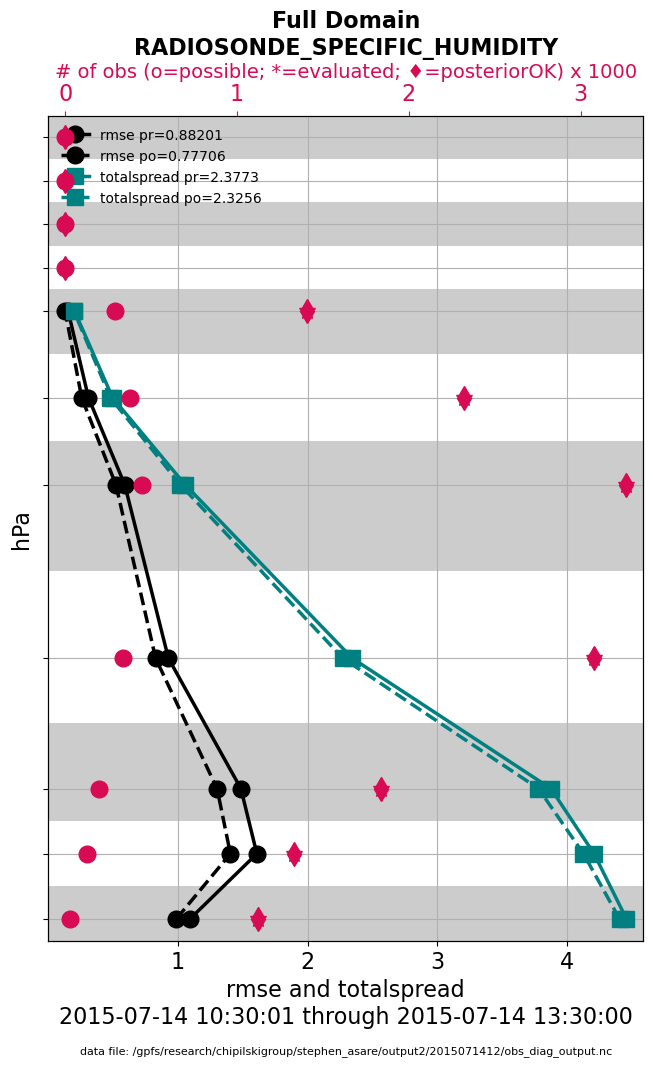

In [20]:
fname = '/gpfs/research/chipilskigroup/stephen_asare/output2/2015071412/obs_diag_output.nc';
copy = 'totalspread';
plot_rmse_xxx_profile(fname, copy, obsname="RADIOSONDE_SPECIFIC_HUMIDITY", yrange=(0, 10), verbose=0)
plt.show()

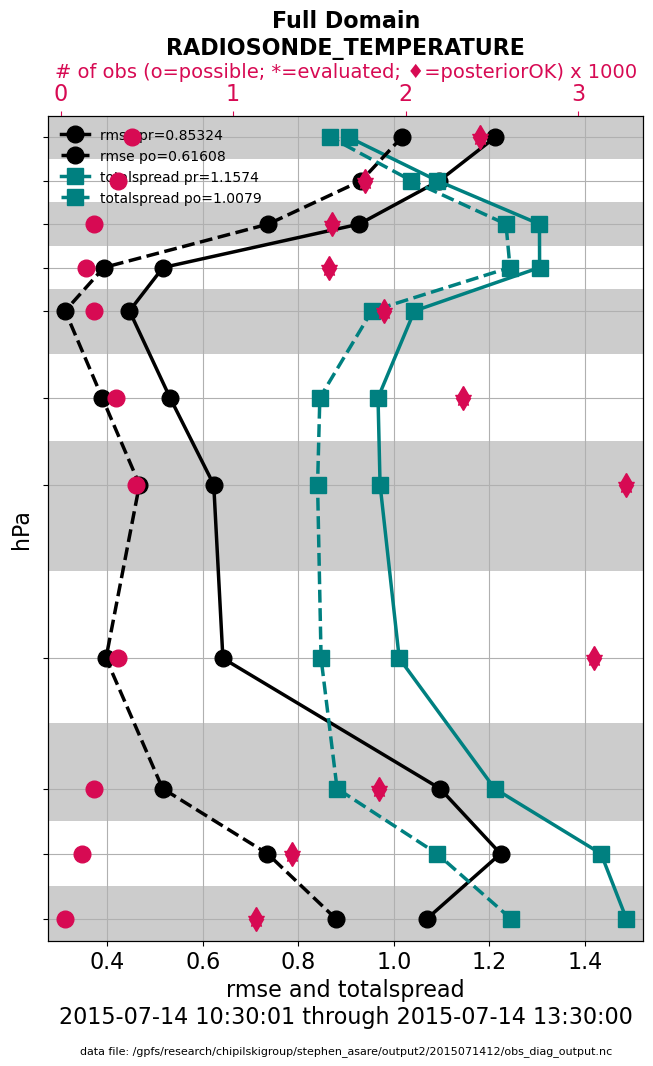

In [21]:
fname = '/gpfs/research/chipilskigroup/stephen_asare/output2/2015071412/obs_diag_output.nc';
copy = 'totalspread';
obsname = 'RADIOSONDE_TEMPERATURE';
plot_rmse_xxx_profile(fname, copy, obsname="RADIOSONDE_TEMPERATURE", yrange=(0, 10), verbose=0)
plt.show()